<a href="https://colab.research.google.com/github/fiorentinaChang/Market-Risk-Framework-for-a-Multi-Asset-Futures/blob/main/multi-asset-futures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# Market Risk Framework for a Multi-Asset Futures Portfolio:
# Volatility Targeting, VaR/ES Backtesting, Stress Testing, and Implementation Costs
#
# Core strategy:
#   Equal-weight diversified futures basket
#   + monthly rebalance
#   + volatility targeting
#   + realistic implementation-cost model
#
# Risk-management framework:
#   + VaR backtesting
#   + expected shortfall diagnostics
#   + stress-window tests
#   + turnover and liquidity-cost sensitivity
#   + model-risk diagnostics
# =============================================================================

from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import chi2

from IPython.display import display

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# =============================================================================
# 1. Configuration
# =============================================================================

equity_futures = ["ES=F", "NQ=F", "YM=F"]

bond_futures = ["ZN=F", "ZB=F", "ZF=F"]

commodity_futures = [
    "GC=F", "SI=F",
    "NG=F",
    "ZC=F", "ZW=F", "ZS=F",
]

commodity_subclass_map = {
    "GC=F": "Metal",
    "SI=F": "Metal",
    "NG=F": "Energy",
    "ZC=F": "Agriculture",
    "ZW=F": "Agriculture",
    "ZS=F": "Agriculture",
}

tickers = equity_futures + bond_futures + commodity_futures
expected_number_of_futures = len(tickers)

risk_free_ticker = "^IRX"

# =============================================================================
# Tactical VIX futures hedge overlay
# =============================================================================
# VIXY is used as an investable proxy for short-term VIX futures exposure.
# It should NOT be included in the equal-weight futures basket.
tail_hedge_ticker = "VIXY"
tail_hedge_name = "Tactical VIX Futures Proxy"

tail_hedge_enabled = True

# Small tactical hedge sizes.
# These are portfolio weights before volatility targeting.
tail_hedge_warning_weight = 0.02
tail_hedge_crisis_weight = 0.04
tail_hedge_max_weight = 0.04

# Hedge activation thresholds.
tail_hedge_spy_drawdown_warning = -0.05
tail_hedge_spy_drawdown_crisis = -0.10
tail_hedge_spy_momentum_lookback = 21
tail_hedge_vixy_momentum_lookback = 5

# The hedge should be funded from risky sleeves, not added as pure extra leverage.
tail_hedge_funding_asset_classes = ["Equity", "Commodity"]

# VIX futures products are more expensive to trade/roll than index futures.
tail_hedge_transaction_cost_bps = 8.0


# Extra benchmark ETFs used only for comparison.
# IEF = 7-10Y Treasury ETF, used for a simple 60/40 proxy.
# DBMF and KMLM are managed-futures ETF proxies. They have shorter histories.

extra_benchmark_tickers = ["IEF", "DBMF", "KMLM"]

benchmark_tickers = (
    tickers
    + ["SPY", risk_free_ticker, tail_hedge_ticker]
    + extra_benchmark_tickers
)

market_names = {
    "ES=F": "S&P 500 futures",
    "NQ=F": "Nasdaq 100 futures",
    "YM=F": "Dow futures",
    "RTY=F": "Russell 2000 futures",
    "ZN=F": "10Y Treasury futures",
    "ZB=F": "30Y Treasury futures",
    "ZF=F": "5Y Treasury futures",
    "GC=F": "Gold futures",
    "SI=F": "Silver futures",
    "NG=F": "Natural gas futures",
    "ZC=F": "Corn futures",
    "ZW=F": "Wheat futures",
    "ZS=F": "Soybean futures",
}

asset_class_map = {}

for t in equity_futures:
    asset_class_map[t] = "Equity"

for t in bond_futures:
    asset_class_map[t] = "Bond"

for t in commodity_futures:
    asset_class_map[t] = "Commodity"

# Data window.
data_start = "1999-01-01"
end = "2026-06-01"

# Main evaluation window.
# For GitHub/recruiting, a long main window is more defensible.
evaluation_start = "2003-01-01"

# Recent evaluation window retained as a separate diagnostic.
recent_evaluation_start = "2025-01-01"

# =============================================================================
# Base strategy parameters
# =============================================================================
target_vol = 0.14
max_leverage = 1.60
min_leverage = 0.50
rebalance_rule = "ME"
vol_lookback = 63

# Keep gross-cap variables only for compatibility with existing functions.
# In the simplified base model, they are neutralized.
normal_gross_cap = max_leverage
warning_gross_cap = max_leverage
crisis_gross_cap = max_leverage

# Neutralize SPY regime overlay.
warning_spy_trend_threshold = -1.00
crisis_spy_trend_threshold = -1.00
equity_crisis_multiplier = 1.00
bond_hedge_weight = 0.00

# Disable trend filter in base model.
trend_filter_enabled = False
trend_lookback = 252
trend_filter_mode = "long_flat"
trend_filter_asset_classes = []

# Disable drawdown de-risking in base model.
# Drawdown is used as a risk diagnostic, not a trading rule.
drawdown_derisking_enabled = False
drawdown_warning_threshold = -0.10
drawdown_crisis_threshold = -0.16
drawdown_warning_multiplier = 1.00
drawdown_crisis_multiplier = 1.00

# =============================================================================
# Transaction-cost and data-validation assumptions
# =============================================================================
# Fallback transaction cost, in basis points per unit of absolute turnover.
transaction_cost_bps = 2.0

# =============================================================================
# Implementation-cost assumptions
# =============================================================================
# Costs are in basis points per unit of absolute notional turnover.
# These are research assumptions used for implementation-risk testing.

implementation_cost_components_bps = {
    "ES=F": {"bid_ask": 0.75, "commission_exchange": 0.25, "slippage": 0.50, "roll": 0.25, "market_impact": 0.25},
    "NQ=F": {"bid_ask": 1.00, "commission_exchange": 0.30, "slippage": 0.75, "roll": 0.25, "market_impact": 0.35},
    "YM=F": {"bid_ask": 1.00, "commission_exchange": 0.30, "slippage": 0.75, "roll": 0.25, "market_impact": 0.35},

    "ZN=F": {"bid_ask": 0.50, "commission_exchange": 0.20, "slippage": 0.40, "roll": 0.20, "market_impact": 0.20},
    "ZB=F": {"bid_ask": 0.75, "commission_exchange": 0.20, "slippage": 0.50, "roll": 0.20, "market_impact": 0.25},
    "ZF=F": {"bid_ask": 0.50, "commission_exchange": 0.20, "slippage": 0.40, "roll": 0.20, "market_impact": 0.20},

    "GC=F": {"bid_ask": 1.00, "commission_exchange": 0.30, "slippage": 0.75, "roll": 0.30, "market_impact": 0.40},
    "SI=F": {"bid_ask": 1.75, "commission_exchange": 0.35, "slippage": 1.25, "roll": 0.50, "market_impact": 0.75},

    "NG=F": {"bid_ask": 3.00, "commission_exchange": 0.40, "slippage": 2.50, "roll": 1.25, "market_impact": 1.50},

    "ZC=F": {"bid_ask": 2.00, "commission_exchange": 0.40, "slippage": 1.50, "roll": 0.75, "market_impact": 1.00},
    "ZW=F": {"bid_ask": 2.50, "commission_exchange": 0.40, "slippage": 2.00, "roll": 0.75, "market_impact": 1.25},
    "ZS=F": {"bid_ask": 2.00, "commission_exchange": 0.40, "slippage": 1.50, "roll": 0.75, "market_impact": 1.00},
}

transaction_cost_bps_by_ticker = {
    ticker: sum(component_costs.values())
    for ticker, component_costs in implementation_cost_components_bps.items()
}

# Add separate cost assumption for the VIX futures proxy.
transaction_cost_bps_by_ticker[tail_hedge_ticker] = tail_hedge_transaction_cost_bps

transaction_cost_bps = float(np.mean(list(transaction_cost_bps_by_ticker.values())))

# Annual financing spread applied only to gross exposure above 1.0.
margin_financing_spread = 0.015

# Liquidity stress multiplier used in cost sensitivity.
liquidity_stress_multiplier = 3.0


stressed_transaction_cost_bps_by_ticker = {
    ticker: cost_bps * liquidity_stress_multiplier
    for ticker, cost_bps in transaction_cost_bps_by_ticker.items()
}


In [ ]:
# =============================================================================
# 2. Data download and cleaning
# =============================================================================

raw = yf.download(
    benchmark_tickers,
    start=data_start,
    end=end,
    auto_adjust=True,
    progress=False,
)["Close"]

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

missing_tickers = [t for t in tickers if t not in raw.columns]

if missing_tickers:
    raise ValueError(f"Missing expected tickers from downloaded data: {missing_tickers}")

prices = raw[tickers].copy()

# Keep only dates where all selected futures have prices.
# This avoids implicit missing-return treatment in the backtest.
prices = prices.dropna(how="any")

spy = raw["SPY"].reindex(prices.index).ffill().dropna()

# Tactical VIX futures proxy price series.
# Kept separate from core futures prices so it does not enter the base basket.
tail_hedge_prices = (
    raw[tail_hedge_ticker]
    .reindex(prices.index)
    .ffill()
)

returns = prices.pct_change(fill_method=None).dropna(how="any")
prices = prices.loc[returns.index]
spy = spy.loc[returns.index]

tail_hedge_prices = tail_hedge_prices.reindex(returns.index).ffill()

spy_returns_clean = spy.pct_change(fill_method=None).dropna()

extra_benchmark_prices = raw[extra_benchmark_tickers].reindex(returns.index).ffill()
extra_benchmark_returns = extra_benchmark_prices.pct_change(fill_method=None)

# ^IRX is quoted as an annualized percentage yield.
# Convert it to an approximate daily risk-free return.
risk_free_yield = raw[risk_free_ticker].reindex(returns.index).ffill() / 100.0
risk_free_daily = risk_free_yield / 252.0
risk_free_daily = risk_free_daily.reindex(returns.index).fillna(0.0)

if prices.shape[1] != expected_number_of_futures:
    raise ValueError(
        f"Expected {expected_number_of_futures} futures contracts, "
        f"but found {prices.shape[1]}: {list(prices.columns)}"
    )

print("Futures used:")
for t in prices.columns:
    print(t, "-", market_names.get(t, t))

print("\nData window:")
print("Start:", prices.index.min())
print("End:  ", prices.index.max())
print("Number of futures used:", len(prices.columns))

print("\nMissing values after cleaning:")
print(prices.isna().sum())

print("\nFinal futures universe:")
print(list(prices.columns))

print("\nReturn window:")
print("Start:", returns.index.min())
print("End:  ", returns.index.max())
print("Number of return observations:", len(returns))

Futures used:
ES=F - S&P 500 futures
NQ=F - Nasdaq 100 futures
YM=F - Dow futures
ZN=F - 10Y Treasury futures
ZB=F - 30Y Treasury futures
ZF=F - 5Y Treasury futures
GC=F - Gold futures
SI=F - Silver futures
NG=F - Natural gas futures
ZC=F - Corn futures
ZW=F - Wheat futures
ZS=F - Soybean futures

Data window:
Start: 2002-04-08 00:00:00
End:   2026-05-29 00:00:00
Number of futures used: 12

Missing values after cleaning:
Ticker
ES=F    0
NQ=F    0
YM=F    0
ZN=F    0
ZB=F    0
ZF=F    0
GC=F    0
SI=F    0
NG=F    0
ZC=F    0
ZW=F    0
ZS=F    0
dtype: int64

Final futures universe:
['ES=F', 'NQ=F', 'YM=F', 'ZN=F', 'ZB=F', 'ZF=F', 'GC=F', 'SI=F', 'NG=F', 'ZC=F', 'ZW=F', 'ZS=F']

Return window:
Start: 2002-04-08 00:00:00
End:   2026-05-29 00:00:00
Number of return observations: 6041


In [ ]:
# =============================================================================
# 3. Performance and risk metric functions
# =============================================================================

def drawdown_series(r: pd.Series) -> pd.Series:
    """
    Calculate drawdown series from returns.
    """
    r = r.dropna()
    equity = (1.0 + r).cumprod()
    return equity / equity.cummax() - 1.0


def performance_stats(
    r: pd.Series,
    risk_free_daily: Optional[pd.Series] = None,
    spy_returns: Optional[pd.Series] = None,
) -> pd.Series:
    """
    Calculate standard performance statistics.

    Sharpe and Sortino are calculated using daily excess returns when a daily
    risk-free return series is provided. Otherwise, they assume a zero
    risk-free rate.

    Beta and correlation are calculated relative to SPY when spy_returns is
    provided.
    """
    r = r.dropna()

    if r.empty:
        return pd.Series({
            "Annual Return": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe": np.nan,
            "Sortino": np.nan,
            "Max Drawdown": np.nan,
            "Calmar": np.nan,
            "Win Rate": np.nan,
            "Worst Month": np.nan,
            "Best Month": np.nan,
            "Beta to SPY": np.nan,
            "Correlation to SPY": np.nan,
            "Total Return": np.nan,
        })

    if risk_free_daily is not None:
        rf = risk_free_daily.reindex(r.index).ffill().fillna(0.0)
        excess_r = r - rf
    else:
        excess_r = r.copy()

    cumulative = (1.0 + r).cumprod()

    ann_return = cumulative.iloc[-1] ** (252.0 / len(r)) - 1.0
    ann_vol = r.std() * np.sqrt(252.0)

    ann_excess_return = excess_r.mean() * 252.0
    excess_vol = excess_r.std() * np.sqrt(252.0)
    sharpe = ann_excess_return / excess_vol if excess_vol > 0.0 else np.nan

    downside_excess_r = excess_r[excess_r < 0.0]
    downside_vol = downside_excess_r.std() * np.sqrt(252.0)
    sortino = ann_excess_return / downside_vol if downside_vol > 0.0 else np.nan

    dd = drawdown_series(r)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0.0 else np.nan

    win_rate = (r > 0.0).mean()

    monthly_r = r.resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0)
    worst_month = monthly_r.min()
    best_month = monthly_r.max()

    if spy_returns is not None:
        aligned_beta = pd.concat(
            {
                "asset": r,
                "spy": spy_returns,
            },
            axis=1,
        ).dropna()

        if not aligned_beta.empty and aligned_beta["spy"].var() > 0.0:
            beta_to_spy = (
                aligned_beta["asset"].cov(aligned_beta["spy"])
                / aligned_beta["spy"].var()
            )
            corr_to_spy = aligned_beta["asset"].corr(aligned_beta["spy"])
        else:
            beta_to_spy = np.nan
            corr_to_spy = np.nan
    else:
        beta_to_spy = np.nan
        corr_to_spy = np.nan

    return pd.Series({
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Win Rate": win_rate,
        "Worst Month": worst_month,
        "Best Month": best_month,
        "Beta to SPY": beta_to_spy,
        "Correlation to SPY": corr_to_spy,
        "Total Return": cumulative.iloc[-1] - 1.0,
    })


def risk_stats(r: pd.Series) -> pd.Series:
    """
    Calculate historical risk-management statistics.

    VaR and Expected Shortfall are reported as positive loss numbers.
    """
    r = r.dropna()

    if r.empty:
        return pd.Series({
            "Daily VaR 95": np.nan,
            "Daily Expected Shortfall 95": np.nan,
            "Daily VaR 99": np.nan,
            "Daily Expected Shortfall 99": np.nan,
            "Average Drawdown": np.nan,
            "Time Under Water": np.nan,
            "Tail Ratio": np.nan,
            "Skew": np.nan,
            "Excess Kurtosis": np.nan,
            "Worst Day": np.nan,
            "Best Day": np.nan,
        })

    var_95_raw = r.quantile(0.05)
    var_99_raw = r.quantile(0.01)

    es_95_raw = r[r <= var_95_raw].mean()
    es_99_raw = r[r <= var_99_raw].mean()

    dd = drawdown_series(r)
    avg_drawdown = dd[dd < 0.0].mean()
    time_under_water = (dd < 0.0).mean()

    upper_tail = r.quantile(0.95)
    lower_tail = r.quantile(0.05)
    tail_ratio = upper_tail / abs(lower_tail) if lower_tail < 0.0 else np.nan

    return pd.Series({
        "Daily VaR 95": -var_95_raw,
        "Daily Expected Shortfall 95": -es_95_raw,
        "Daily VaR 99": -var_99_raw,
        "Daily Expected Shortfall 99": -es_99_raw,
        "Average Drawdown": avg_drawdown,
        "Time Under Water": time_under_water,
        "Tail Ratio": tail_ratio,
        "Skew": r.skew(),
        "Excess Kurtosis": r.kurtosis(),
        "Worst Day": r.min(),
        "Best Day": r.max(),
    })


def rolling_var_breach_summary(
    r: pd.Series,
    window: int = 252,
    confidence: float = 0.95,
) -> pd.Series:
    """
    Calculate rolling historical VaR breaches.

    VaR is estimated using only trailing returns.
    A breach occurs when the next return is below the trailing VaR threshold.
    """
    r = r.dropna()

    if len(r) <= window:
        return pd.Series({
            "VaR Confidence": confidence,
            "VaR Window": window,
            "VaR Breach Rate": np.nan,
            "Expected Breach Rate": 1.0 - confidence,
            "Number of Breaches": np.nan,
            "Number of Observations": np.nan,
        })

    q = 1.0 - confidence
    rolling_threshold = r.rolling(window).quantile(q).shift(1)

    aligned = pd.concat(
        {
            "return": r,
            "threshold": rolling_threshold,
        },
        axis=1,
    ).dropna()

    breaches = aligned["return"] < aligned["threshold"]

    return pd.Series({
        "VaR Confidence": confidence,
        "VaR Window": window,
        "VaR Breach Rate": breaches.mean(),
        "Expected Breach Rate": 1.0 - confidence,
        "Number of Breaches": breaches.sum(),
        "Number of Observations": len(breaches),
    })

def rolling_var_backtest_frame(
    r: pd.Series,
    window: int = 252,
    confidence: float = 0.99,
) -> pd.DataFrame:
    """
    Build a rolling historical VaR backtest frame.

    The VaR threshold is estimated using only trailing returns.
    A breach occurs when today's return is below yesterday's estimated VaR threshold.
    """
    r = r.dropna()
    q = 1.0 - confidence

    rolling_var_threshold = r.rolling(window).quantile(q).shift(1)

    out = pd.DataFrame({
        "Return": r,
        "VaR Threshold": rolling_var_threshold,
    }).dropna()

    out["Breach"] = out["Return"] < out["VaR Threshold"]
    out["Loss"] = -out["Return"]
    out["VaR Loss"] = -out["VaR Threshold"]

    return out


def kupiec_pof_test(
    breaches: pd.Series,
    expected_breach_prob: float,
) -> pd.Series:
    """
    Kupiec proportion-of-failures test.

    Null hypothesis:
        observed breach frequency equals expected breach probability.

    Returns LR statistic and chi-square p-value with 1 degree of freedom.
    """
    b = breaches.dropna().astype(bool)
    n = len(b)
    x = int(b.sum())

    if n == 0:
        return pd.Series({
            "Observations": np.nan,
            "Breaches": np.nan,
            "Expected Breach Probability": expected_breach_prob,
            "Observed Breach Rate": np.nan,
            "Kupiec LR": np.nan,
            "Kupiec p-value": np.nan,
            "Reject 5%": np.nan,
        })

    pi_hat = x / n

    eps = 1e-12
    p = np.clip(expected_breach_prob, eps, 1.0 - eps)
    pi_hat_clipped = np.clip(pi_hat, eps, 1.0 - eps)

    log_l_null = (n - x) * np.log(1.0 - p) + x * np.log(p)
    log_l_alt = (n - x) * np.log(1.0 - pi_hat_clipped) + x * np.log(pi_hat_clipped)

    lr = -2.0 * (log_l_null - log_l_alt)
    p_value = 1.0 - chi2.cdf(lr, df=1)

    return pd.Series({
        "Observations": n,
        "Breaches": x,
        "Expected Breach Probability": expected_breach_prob,
        "Observed Breach Rate": pi_hat,
        "Kupiec LR": lr,
        "Kupiec p-value": p_value,
        "Reject 5%": p_value < 0.05,
    })


def christoffersen_independence_test(
    breaches: pd.Series,
) -> pd.Series:
    """
    Christoffersen independence test for VaR breach clustering.

    Null hypothesis:
        breaches are independent over time.

    This tests whether a breach is more likely after a previous breach.
    """
    b = breaches.dropna().astype(int)

    if len(b) < 2:
        return pd.Series({
            "N00": np.nan,
            "N01": np.nan,
            "N10": np.nan,
            "N11": np.nan,
            "Christoffersen LR Independence": np.nan,
            "Christoffersen p-value": np.nan,
            "Reject 5%": np.nan,
        })

    prev_b = b.shift(1).dropna().astype(int)
    curr_b = b.loc[prev_b.index].astype(int)

    n00 = int(((prev_b == 0) & (curr_b == 0)).sum())
    n01 = int(((prev_b == 0) & (curr_b == 1)).sum())
    n10 = int(((prev_b == 1) & (curr_b == 0)).sum())
    n11 = int(((prev_b == 1) & (curr_b == 1)).sum())

    eps = 1e-12

    pi01 = n01 / max(n00 + n01, 1)
    pi11 = n11 / max(n10 + n11, 1)
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    pi01 = np.clip(pi01, eps, 1.0 - eps)
    pi11 = np.clip(pi11, eps, 1.0 - eps)
    pi = np.clip(pi, eps, 1.0 - eps)

    log_l_independent = (
        (n00 + n10) * np.log(1.0 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_l_markov = (
        n00 * np.log(1.0 - pi01)
        + n01 * np.log(pi01)
        + n10 * np.log(1.0 - pi11)
        + n11 * np.log(pi11)
    )

    lr_ind = -2.0 * (log_l_independent - log_l_markov)
    p_value = 1.0 - chi2.cdf(lr_ind, df=1)

    return pd.Series({
        "N00": n00,
        "N01": n01,
        "N10": n10,
        "N11": n11,
        "P Breach After No Breach": pi01,
        "P Breach After Breach": pi11,
        "Christoffersen LR Independence": lr_ind,
        "Christoffersen p-value": p_value,
        "Reject 5%": p_value < 0.05,
    })


def basel_traffic_light(
    breaches: pd.Series,
    window: int = 250,
) -> pd.Series:
    """
    Basel-style traffic-light classification for 99% VaR over a 250-day window.

    Green: 0-4 exceptions
    Yellow: 5-9 exceptions
    Red: 10+ exceptions
    """
    recent = breaches.dropna().astype(bool).tail(window)
    n_breaches = int(recent.sum())

    if n_breaches <= 4:
        zone = "Green"
    elif n_breaches <= 9:
        zone = "Yellow"
    else:
        zone = "Red"

    return pd.Series({
        "Window": len(recent),
        "Breaches": n_breaches,
        "Basel Zone": zone,
    })


def var_exceedance_clustering(
    breaches: pd.Series,
) -> pd.Series:
    """
    Simple VaR exceedance clustering diagnostics.

    Reports:
    - longest consecutive breach run
    - average gap between breaches
    - share of breaches that occur immediately after another breach
    """
    b = breaches.dropna().astype(bool)

    if b.empty or b.sum() == 0:
        return pd.Series({
            "Number of Breaches": int(b.sum()) if not b.empty else np.nan,
            "Longest Breach Cluster": 0,
            "Average Days Between Breaches": np.nan,
            "Share Consecutive Breaches": np.nan,
        })

    breach_dates = b[b].index
    gaps = pd.Series(breach_dates).diff().dt.days.dropna()

    longest_cluster = 0
    current_cluster = 0

    for value in b.values:
        if value:
            current_cluster += 1
            longest_cluster = max(longest_cluster, current_cluster)
        else:
            current_cluster = 0

    consecutive_breaches = (b & b.shift(1).fillna(False)).sum()
    share_consecutive = consecutive_breaches / b.sum()

    return pd.Series({
        "Number of Breaches": int(b.sum()),
        "Longest Breach Cluster": int(longest_cluster),
        "Average Days Between Breaches": gaps.mean() if not gaps.empty else np.nan,
        "Share Consecutive Breaches": share_consecutive,
    })


def formal_var_backtest_summary(
    r: pd.Series,
    window: int = 252,
    confidence: float = 0.99,
) -> pd.Series:
    """
    Combined formal VaR backtesting summary:
    - Kupiec POF
    - Christoffersen independence
    - Basel traffic light
    - exceedance clustering
    """
    bt = rolling_var_backtest_frame(r, window=window, confidence=confidence)
    expected_prob = 1.0 - confidence

    kupiec = kupiec_pof_test(bt["Breach"], expected_prob)
    christoffersen = christoffersen_independence_test(bt["Breach"])
    basel = basel_traffic_light(bt["Breach"], window=250)
    clustering = var_exceedance_clustering(bt["Breach"])

    return pd.concat({
        "Kupiec": kupiec,
        "Christoffersen": christoffersen,
        "Basel": basel,
        "Clustering": clustering,
    })


def rolling_es_backtest_frame(
    r: pd.Series,
    window: int = 252,
    confidence: float = 0.975,
) -> pd.DataFrame:
    """
    Rolling historical ES diagnostic frame.

    ES is estimated as the average loss beyond the trailing VaR threshold.
    This is a practical ES severity diagnostic, not a full Acerbi-Szekely test.
    """
    r = r.dropna()
    q = 1.0 - confidence

    rolling_var_threshold = r.rolling(window).quantile(q).shift(1)

    rolling_es_threshold = (
        r.rolling(window)
        .apply(lambda x: x[x <= np.quantile(x, q)].mean(), raw=False)
        .shift(1)
    )

    out = pd.DataFrame({
        "Return": r,
        "VaR Threshold": rolling_var_threshold,
        "ES Threshold": rolling_es_threshold,
    }).dropna()

    out["VaR Breach"] = out["Return"] < out["VaR Threshold"]
    out["Loss"] = -out["Return"]
    out["VaR Loss"] = -out["VaR Threshold"]
    out["ES Loss Forecast"] = -out["ES Threshold"]
    out["Loss Minus ES Forecast"] = out["Loss"] - out["ES Loss Forecast"]

    return out


def es_severity_summary(
    r: pd.Series,
    window: int = 252,
    confidence: float = 0.975,
) -> pd.Series:
    """
    Expected shortfall severity diagnostic.

    Useful risk-management questions:
    - when VaR is breached, is the realized loss worse than the ES forecast?
    - how large is the average breach loss relative to ES?
    """
    bt = rolling_es_backtest_frame(r, window=window, confidence=confidence)
    breaches = bt[bt["VaR Breach"]]

    if breaches.empty:
        return pd.Series({
            "ES Confidence": confidence,
            "VaR Breaches": 0,
            "Average Breach Loss": np.nan,
            "Average VaR Forecast": np.nan,
            "Average ES Forecast": np.nan,
            "Average Loss / ES Forecast": np.nan,
            "Share Loss Worse Than ES": np.nan,
            "Worst Breach Loss": np.nan,
        })

    return pd.Series({
        "ES Confidence": confidence,
        "VaR Breaches": len(breaches),
        "Average Breach Loss": breaches["Loss"].mean(),
        "Average VaR Forecast": breaches["VaR Loss"].mean(),
        "Average ES Forecast": breaches["ES Loss Forecast"].mean(),
        "Average Loss / ES Forecast": (
            breaches["Loss"].mean() / breaches["ES Loss Forecast"].mean()
            if breaches["ES Loss Forecast"].mean() > 0.0
            else np.nan
        ),
        "Share Loss Worse Than ES": (
            breaches["Loss"] > breaches["ES Loss Forecast"]
        ).mean(),
        "Worst Breach Loss": breaches["Loss"].max(),
    })

def realized_vol_tracking(
    r: pd.Series,
    target_vol: float,
    window: int = 63,
) -> pd.Series:
    """
    Assess whether realized volatility is close to target volatility.
    """
    r = r.dropna()
    rolling_vol = r.rolling(window).std() * np.sqrt(252.0)
    rolling_vol = rolling_vol.dropna()

    if rolling_vol.empty:
        return pd.Series({
            "Target Vol": target_vol,
            "Average Realized Vol": np.nan,
            "Median Realized Vol": np.nan,
            "Realized Vol Tracking Error": np.nan,
            "Max Realized Vol": np.nan,
        })

    return pd.Series({
        "Target Vol": target_vol,
        "Average Realized Vol": rolling_vol.mean(),
        "Median Realized Vol": rolling_vol.median(),
        "Realized Vol Tracking Error": (rolling_vol - target_vol).std(),
        "Max Realized Vol": rolling_vol.max(),
    })


def upside_downside_capture(
    strategy_returns: pd.Series,
    benchmark_returns: pd.Series,
) -> pd.Series:
    """
    Calculate upside and downside capture versus a benchmark.

    Upside capture:
        average strategy return on days benchmark is positive
        divided by average benchmark return on those days.

    Downside capture:
        average strategy return on days benchmark is negative
        divided by average benchmark return on those days.

    For downside capture, lower positive values are generally better.
    Negative values can mean the strategy was positive when the benchmark was down.
    """
    aligned = pd.concat(
        {
            "strategy": strategy_returns,
            "benchmark": benchmark_returns,
        },
        axis=1,
    ).dropna()

    if aligned.empty:
        return pd.Series({
            "Upside Capture vs SPY": np.nan,
            "Downside Capture vs SPY": np.nan,
        })

    up = aligned[aligned["benchmark"] > 0.0]
    down = aligned[aligned["benchmark"] < 0.0]

    upside_capture = (
        up["strategy"].mean() / up["benchmark"].mean()
        if len(up) > 0 and up["benchmark"].mean() != 0.0
        else np.nan
    )

    downside_capture = (
        down["strategy"].mean() / down["benchmark"].mean()
        if len(down) > 0 and down["benchmark"].mean() != 0.0
        else np.nan
    )

    return pd.Series({
        "Upside Capture vs SPY": upside_capture,
        "Downside Capture vs SPY": downside_capture,
    })


def worst_days_table(
    comparison: pd.DataFrame,
    series_name: str,
    n: int = 20,
) -> pd.DataFrame:
    """
    Return the worst n daily returns for one series, with all comparison columns.
    """
    worst_dates = comparison[series_name].nsmallest(n).index
    out = comparison.loc[worst_dates].copy()
    out = out.sort_values(series_name)
    out.insert(0, "Rank", range(1, len(out) + 1))
    return out


def format_stats(stats: pd.DataFrame) -> pd.DataFrame:
    """
    Format performance and risk statistics for display.
    """
    formatted = stats.copy()

    percent_cols = [
        "Annual Return",
        "Annual Volatility",
        "Max Drawdown",
        "Win Rate",
        "Worst Month",
        "Best Month",
        "Total Return",
        "Daily VaR 95",
        "Daily Expected Shortfall 95",
        "Daily VaR 99",
        "Daily Expected Shortfall 99",
        "Average Drawdown",
        "Time Under Water",
        "Worst Day",
        "Best Day",
        "VaR Breach Rate",
        "Expected Breach Rate",
        "Target Vol",
        "Average Realized Vol",
        "Median Realized Vol",
        "Realized Vol Tracking Error",
        "Max Realized Vol",
        "Upside Capture vs SPY",
        "Downside Capture vs SPY",
        "Estimated Portfolio Return",
        "Largest Positive Contribution",
        "Largest Negative Contribution",
        "Empirical One-Day Vol",
        "Empirical Normal VaR",
        "Full-Correlation One-Day Vol",
        "Full-Correlation Normal VaR",
        "Correlation Breakdown VaR Uplift",
        "Volatility Doubling VaR",
        "Latest Effective Weight",
        "Marginal Vol Contribution",
        "Component Vol Contribution",
        "Pct Vol Contribution",
        "Component Historical VaR Contribution",
        "Net_Exposure",
        "Gross_Exposure",
        "Drawdown Contribution",
        "Loss Contribution",
        "Average Breach Loss",
        "Average VaR Forecast",
        "Average ES Forecast",
        "Average Loss / ES Forecast",
        "Share Loss Worse Than ES",
        "Worst Breach Loss",
        "Observed Breach Rate",
        "Expected Breach Probability",
        "P Breach After No Breach",
        "P Breach After Breach",
        "Share Consecutive Breaches",
    ]

    number_cols = [
        "Sharpe",
        "Sortino",
        "Calmar",
        "Beta to SPY",
        "Correlation to SPY",
        "Tail Ratio",
        "Skew",
        "Excess Kurtosis",
        "VaR Confidence",
        "VaR Window",
        "Number of Breaches",
        "Number of Observations",
        "Average Leverage",
        "Median Leverage",
        "Max Leverage",
        "Warning Regime Days",
        "Crisis Regime Days",
        "Drawdown Derisking Days",
    ]

    for col in percent_cols:
        if col in formatted.columns:
            formatted[col] = formatted[col].map(
                lambda x: f"{x:.2%}" if pd.notna(x) else ""
            )

    for col in number_cols:
        if col in formatted.columns:
            formatted[col] = formatted[col].map(
                lambda x: f"{x:.2f}" if pd.notna(x) else ""
            )

    return formatted


def format_return_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Format a return table for display.
    """
    formatted = df.copy()

    for col in formatted.columns:
        if col != "Rank":
            formatted[col] = formatted[col].map(
                lambda x: f"{x:.2%}" if pd.notna(x) else ""
            )

    return formatted


def latest_effective_weight_vector(
    effective_weights: pd.DataFrame,
) -> pd.Series:
    """
    Return latest available effective portfolio weights.
    """
    w = effective_weights.dropna(how="all").iloc[-1].fillna(0.0)
    return w


def hypothetical_scenario_analysis(
    latest_weights: pd.Series,
) -> pd.DataFrame:
    """
    Simple one-day hypothetical shock scenarios.

    Notes:
    - Rate shocks are approximated using rough duration-style price shocks.
    - USD shock is marked as not applicable unless FX futures are added.
    - Scenario P&L is approximate because the Yahoo futures data are price-return proxies.
    """
    assets = latest_weights.index

    scenarios = {}

    # Equity shock.
    shock = pd.Series(0.0, index=assets)
    for t in ["ES=F", "NQ=F", "YM=F"]:
        if t in shock.index:
            shock[t] = -0.10
    scenarios["Equity -10%"] = shock

    # Rates +100 bps, rough futures price impact approximations.
    shock = pd.Series(0.0, index=assets)
    if "ZF=F" in shock.index:
        shock["ZF=F"] = -0.045
    if "ZN=F" in shock.index:
        shock["ZN=F"] = -0.080
    if "ZB=F" in shock.index:
        shock["ZB=F"] = -0.180
    scenarios["Rates +100 bps"] = shock


    # Natural gas shock.
    shock = pd.Series(0.0, index=assets)
    if "NG=F" in shock.index:
        shock["NG=F"] = -0.30
    scenarios["Natural Gas -30%"] = shock

    # Agriculture shock.
    shock = pd.Series(0.0, index=assets)
    for t in ["ZC=F", "ZW=F", "ZS=F"]:
        if t in shock.index:
            shock[t] = -0.15
    scenarios["Agriculture -15%"] = shock

    # Metals shock.
    shock = pd.Series(0.0, index=assets)
    for t in ["GC=F", "SI=F"]:
        if t in shock.index:
            shock[t] = -0.10
    scenarios["Metals -10%"] = shock

    # Broad risk-off.
    shock = pd.Series(0.0, index=assets)
    for t in ["ES=F", "NQ=F", "YM=F"]:
        if t in shock.index:
            shock[t] = -0.08
    for t in ["NG=F", "ZC=F", "ZW=F", "ZS=F", "GC=F", "SI=F"]:
        if t in shock.index:
            shock[t] = -0.05
    for t in ["ZF=F", "ZN=F", "ZB=F"]:
        if t in shock.index:
            shock[t] = 0.03
    scenarios["Broad Risk-Off"] = shock

    rows = []
    for name, shock_vector in scenarios.items():
        aligned_weights = latest_weights.reindex(shock_vector.index).fillna(0.0)
        pnl = aligned_weights * shock_vector

        rows.append({
            "Scenario": name,
            "Estimated Portfolio Return": pnl.sum(),
            "Largest Positive Contributor": pnl.idxmax(),
            "Largest Positive Contribution": pnl.max(),
            "Largest Negative Contributor": pnl.idxmin(),
            "Largest Negative Contribution": pnl.min(),
        })

    return pd.DataFrame(rows).set_index("Scenario")


def correlation_breakdown_var(
    returns: pd.DataFrame,
    latest_weights: pd.Series,
    confidence: float = 0.99,
) -> pd.Series:
    """
    Compare normal one-day VaR under empirical covariance versus full-correlation covariance.
    """
    aligned_returns = returns[latest_weights.index].dropna()
    w = latest_weights.reindex(aligned_returns.columns).fillna(0.0)

    cov_empirical = aligned_returns.cov()
    vols = aligned_returns.std()

    corr_one = pd.DataFrame(
        1.0,
        index=aligned_returns.columns,
        columns=aligned_returns.columns,
    )
    cov_full_corr = corr_one.multiply(vols, axis=0).multiply(vols, axis=1)

    # Normal z-scores.
    z_map = {
        0.95: 1.644854,
        0.975: 1.959964,
        0.99: 2.326348,
    }
    z = z_map.get(confidence, 2.326348)

    vol_empirical = np.sqrt(w @ cov_empirical @ w)
    vol_full_corr = np.sqrt(w @ cov_full_corr @ w)

    return pd.Series({
        "Confidence": confidence,
        "Empirical One-Day Vol": vol_empirical,
        "Empirical Normal VaR": z * vol_empirical,
        "Full-Correlation One-Day Vol": vol_full_corr,
        "Full-Correlation Normal VaR": z * vol_full_corr,
        "Correlation Breakdown VaR Uplift": (
            (z * vol_full_corr) / (z * vol_empirical) - 1.0
            if vol_empirical > 0.0
            else np.nan
        ),
        "Volatility Doubling VaR": 2.0 * z * vol_empirical,
    })

def component_risk_decomposition(
    asset_returns: pd.DataFrame,
    effective_weights: pd.DataFrame,
    confidence: float = 0.95,
    lookback: int = 252,
) -> pd.DataFrame:
    """
    Component risk decomposition using the latest effective weights.

    Reports:
    - latest effective weight
    - marginal contribution to volatility
    - component contribution to volatility
    - component historical VaR contribution
    - asset-class label
    """
    latest_w = latest_effective_weight_vector(effective_weights)

    common_cols = [c for c in latest_w.index if c in asset_returns.columns]
    r = asset_returns[common_cols].dropna().tail(lookback)
    w = latest_w.reindex(common_cols).fillna(0.0)

    cov = r.cov()
    port_vol = np.sqrt(w @ cov @ w)

    if port_vol > 0.0:
        marginal_vol = cov @ w / port_vol
        component_vol = w * marginal_vol
        pct_component_vol = component_vol / port_vol
    else:
        marginal_vol = pd.Series(np.nan, index=common_cols)
        component_vol = pd.Series(np.nan, index=common_cols)
        pct_component_vol = pd.Series(np.nan, index=common_cols)

    asset_contrib = r.multiply(w, axis=1)
    port_r = asset_contrib.sum(axis=1)

    var_threshold = port_r.quantile(1.0 - confidence)
    var_days = port_r <= var_threshold

    if var_days.sum() > 0:
        component_var = -asset_contrib.loc[var_days].mean()
    else:
        component_var = pd.Series(np.nan, index=common_cols)

    out = pd.DataFrame({
        "Asset Class": [asset_class_map.get(c, "Other") for c in common_cols],
        "Latest Effective Weight": w,
        "Marginal Vol Contribution": marginal_vol,
        "Component Vol Contribution": component_vol,
        "Pct Vol Contribution": pct_component_vol,
        "Component Historical VaR Contribution": component_var,
    })

    return out.sort_values("Pct Vol Contribution", ascending=False)


def asset_class_exposure_summary(
    effective_weights: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize latest effective exposure by asset class.
    """
    latest_w = latest_effective_weight_vector(effective_weights)

    df = pd.DataFrame({
        "Ticker": latest_w.index,
        "Asset Class": [asset_class_map.get(t, "Other") for t in latest_w.index],
        "Weight": latest_w.values,
        "Abs Weight": latest_w.abs().values,
    })

    out = df.groupby("Asset Class").agg(
        Net_Exposure=("Weight", "sum"),
        Gross_Exposure=("Abs Weight", "sum"),
    )

    return out.sort_values("Gross_Exposure", ascending=False)


def max_drawdown_contribution(
    asset_returns: pd.DataFrame,
    effective_weights: pd.DataFrame,
    portfolio_returns: pd.Series,
) -> pd.DataFrame:
    """
    Estimate asset contribution during the portfolio's max drawdown period.
    """
    dd = drawdown_series(portfolio_returns)
    trough = dd.idxmin()
    peak = portfolio_returns.loc[:trough].pipe(
        lambda x: (1.0 + x).cumprod()
    ).idxmax()

    common_cols = [c for c in effective_weights.columns if c in asset_returns.columns]

    weights = effective_weights[common_cols].reindex(asset_returns.index).ffill().shift(1)
    contrib = asset_returns[common_cols].multiply(weights, axis=0)

    dd_contrib = contrib.loc[peak:trough].sum()

    out = pd.DataFrame({
        "Asset Class": [asset_class_map.get(c, "Other") for c in dd_contrib.index],
        "Drawdown Contribution": dd_contrib,
    })

    out["Loss Contribution"] = -out["Drawdown Contribution"]

    return out.sort_values("Loss Contribution", ascending=False)

In [ ]:
# =============================================================================
# 4. Plotting functions
# =============================================================================

def plot_equity_curve(
    comparison: pd.DataFrame,
    title: str,
    filename: str = "equity_curve.png",
) -> None:
    """
    Plot cumulative growth of $1.
    """
    equity_curve = (1.0 + comparison).cumprod()

    plt.figure(figsize=(12, 6))
    for col in equity_curve.columns:
        plt.plot(equity_curve.index, equity_curve[col], label=col)

    plt.yscale("log")
    plt.title(title)
    plt.ylabel("Growth of $1, log scale")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_drawdown_curve(
    comparison: pd.DataFrame,
    filename: str = "drawdown.png",
) -> None:
    """
    Plot drawdowns for the strategy and benchmarks.
    """
    equity_curve = (1.0 + comparison).cumprod()
    drawdown = equity_curve / equity_curve.cummax() - 1.0

    ax = drawdown.plot(
        figsize=(12, 6),
        title="Strategy Drawdowns vs Benchmarks",
    )

    ax.set_ylabel("Drawdown")
    ax.axhline(0.0, linewidth=1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_rolling_volatility(
    comparison: pd.DataFrame,
    window: int = 63,
    filename: str = "rolling_volatility.png",
) -> None:
    """
    Plot rolling annualized volatility.
    """
    rolling_vol = comparison.rolling(window).std() * np.sqrt(252.0)

    ax = rolling_vol.plot(
        figsize=(12, 6),
        title=f"Rolling Annualized Volatility ({window}-day)",
    )

    ax.set_ylabel("Annualized Volatility")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_rolling_sharpe(
    comparison: pd.DataFrame,
    window: int = 63,
    filename: str = "rolling_sharpe.png",
) -> None:
    """
    Plot rolling annualized Sharpe ratio.
    """
    rolling_ann_return = comparison.rolling(window).mean() * 252.0
    rolling_ann_vol = comparison.rolling(window).std() * np.sqrt(252.0)

    rolling_sharpe = rolling_ann_return / rolling_ann_vol
    rolling_sharpe = rolling_sharpe.replace([np.inf, -np.inf], np.nan)

    ax = rolling_sharpe.plot(
        figsize=(12, 6),
        title=f"Rolling Sharpe Ratio ({window}-day)",
    )

    ax.set_ylabel("Rolling Sharpe")
    ax.axhline(0.0, linewidth=1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_strategy_underwater(
    strategy_returns: pd.Series,
    filename: str = "underwater_plot.png",
) -> None:
    """
    Plot strategy-only underwater/drawdown chart.
    """
    drawdown = drawdown_series(strategy_returns)

    plt.figure(figsize=(12, 5))
    plt.fill_between(drawdown.index, drawdown.values, 0.0)
    plt.title("Diversified Futures Vol-Target Strategy Underwater Plot")
    plt.ylabel("Drawdown")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_monthly_returns(
    strategy_returns: pd.Series,
    filename: str = "monthly_returns.png",
) -> None:
    """
    Plot monthly returns.
    """
    monthly_returns = strategy_returns.resample("ME").apply(
        lambda x: (1.0 + x).prod() - 1.0
    )

    labels = monthly_returns.index.strftime("%Y-%m")

    plt.figure(figsize=(12, 5))
    plt.bar(labels, monthly_returns.values)
    plt.title("Diversified Futures Vol-Target Strategy Monthly Returns")
    plt.ylabel("Monthly Return")
    plt.xlabel("Month")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_effective_exposure(
    daily_weights: pd.DataFrame,
    leverage: pd.Series,
    freq: str = "ME",
    filename: str = "effective_exposure.png",
) -> None:
    """
    Plot effective gross and net exposure after volatility targeting.
    """
    aligned_leverage = leverage.reindex(daily_weights.index).ffill().fillna(1.0)

    effective_weights = daily_weights.multiply(
        aligned_leverage.shift(1).fillna(1.0),
        axis=0,
    )

    exposure = pd.DataFrame({
        "Effective Gross Exposure": effective_weights.abs().sum(axis=1),
        "Effective Net Exposure": effective_weights.sum(axis=1),
    })

    exposure = exposure.resample(freq).last()

    ax = exposure.plot(
        figsize=(12, 5),
        marker="o",
        title="Effective Portfolio Exposure After Vol Targeting",
    )

    ax.set_ylabel("Exposure")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_effective_asset_weights(
    daily_weights: pd.DataFrame,
    leverage: pd.Series,
    min_abs_weight: float = 0.01,
    freq: str = "ME",
    filename: str = "effective_asset_weights.png",
) -> None:
    """
    Plot effective asset weights after volatility targeting.
    """
    aligned_leverage = leverage.reindex(daily_weights.index).ffill().fillna(1.0)

    effective_weights = daily_weights.multiply(
        aligned_leverage.shift(1).fillna(1.0),
        axis=0,
    )

    effective_weights = effective_weights.resample(freq).last()

    active_cols = [
        col for col in effective_weights.columns
        if effective_weights[col].abs().max() > min_abs_weight
    ]

    if not active_cols:
        print("No effective asset weights above threshold.")
        return

    ax = effective_weights[active_cols].plot(
        figsize=(12, 6),
        marker="o",
        title="Effective Asset Weights After Vol Targeting",
    )

    if tail_hedge_ticker in strategy_daily_weights.columns:
      plot_effective_asset_weights(
        strategy_daily_weights[[tail_hedge_ticker]].loc[pd.Timestamp(evaluation_start):],
        strategy_leverage.loc[pd.Timestamp(evaluation_start):],
        min_abs_weight=0.0001,
        freq="ME",
        filename="tactical_vix_hedge_effective_weight.png",
    )

    ax.set_ylabel("Effective Weight")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()



def plot_rolling_beta_to_spy(
    strategy_returns: pd.Series,
    spy_returns: pd.Series,
    window: int = 63,
    filename: str = "rolling_beta_spy.png",
) -> None:
    """
    Plot rolling beta of the strategy relative to SPY.
    """
    aligned = pd.concat(
        {
            "strategy": strategy_returns,
            "spy": spy_returns,
        },
        axis=1,
    ).dropna()

    rolling_cov = aligned["strategy"].rolling(window).cov(aligned["spy"])
    rolling_var = aligned["spy"].rolling(window).var()

    rolling_beta = rolling_cov / rolling_var
    rolling_beta = rolling_beta.replace([np.inf, -np.inf], np.nan)

    plt.figure(figsize=(12, 5))
    plt.plot(rolling_beta.index, rolling_beta, label="Rolling Beta to SPY")
    plt.axhline(1.0, linewidth=1)
    plt.axhline(0.0, linewidth=1)
    plt.title(f"Rolling Beta to SPY ({window}-day)")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()


def plot_asset_class_exposure(
    daily_weights: pd.DataFrame,
    leverage: pd.Series,
    freq: str = "ME",
    filename: str = "asset_class_exposure.png",
) -> pd.DataFrame:
    """
    Plot and return monthly effective asset-class exposure.
    """
    aligned_leverage = leverage.reindex(daily_weights.index).ffill().fillna(1.0)

    effective_weights = daily_weights.multiply(
        aligned_leverage.shift(1).fillna(1.0),
        axis=0,
    )

    class_exposure = pd.DataFrame(index=effective_weights.index)

    for asset_class in ["Equity", "Bond", "Commodity"]:
        cols = [
            t for t in effective_weights.columns
            if asset_class_map.get(t) == asset_class
        ]

        if len(cols) > 0:
            class_exposure[asset_class + " Gross"] = effective_weights[cols].abs().sum(axis=1)
            class_exposure[asset_class + " Net"] = effective_weights[cols].sum(axis=1)

    class_exposure_monthly = class_exposure.resample(freq).last()

    ax = class_exposure_monthly.plot(
        figsize=(12, 6),
        marker="o",
        title="Effective Monthly Asset-Class Exposure",
    )

    ax.set_ylabel("Effective Exposure")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()

    return class_exposure_monthly


def plot_rolling_var(
    strategy_returns: pd.Series,
    window: int = 252,
    confidence: float = 0.95,
    filename: str = "rolling_var_breach_diagnostic.png",
) -> None:
    """
    Plot rolling historical VaR threshold and realized daily returns.
    """
    r = strategy_returns.dropna()
    q = 1.0 - confidence

    rolling_threshold = r.rolling(window).quantile(q).shift(1)

    plt.figure(figsize=(12, 5))
    plt.plot(r.index, r, label="Daily Return")
    plt.plot(rolling_threshold.index, rolling_threshold, label=f"Rolling {confidence:.0%} VaR Threshold")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"Rolling Historical VaR Breach Diagnostic ({window}-day window)")
    plt.ylabel("Daily Return")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    print("Saved:", OUTPUT_DIR / filename)
    plt.show()

In [ ]:
# =============================================================================
# 5. Strategy and benchmark functions
# =============================================================================

def run_diversified_futures_strategy(
    prices: pd.DataFrame,
    spy: pd.Series,
    tail_hedge_prices: Optional[pd.Series] = None,
    tail_hedge_ticker: str = "VIXY",
    tail_hedge_enabled: bool = False,
    tail_hedge_warning_weight: float = 0.02,
    tail_hedge_crisis_weight: float = 0.04,
    tail_hedge_max_weight: float = 0.04,
    tail_hedge_spy_drawdown_warning: float = -0.05,
    tail_hedge_spy_drawdown_crisis: float = -0.10,
    tail_hedge_spy_momentum_lookback: int = 21,
    tail_hedge_vixy_momentum_lookback: int = 5,
    tail_hedge_funding_asset_classes: Optional[list] = None,
    target_vol: float = 0.14,
    max_leverage: float = 1.35,
    min_leverage: float = 0.60,
    normal_gross_cap: float = 1.30,
    warning_gross_cap: float = 1.05,
    crisis_gross_cap: float = 0.75,
    warning_spy_trend_threshold: float = -0.025,
    crisis_spy_trend_threshold: float = -0.05,
    equity_crisis_multiplier: float = 0.65,
    bond_hedge_weight: float = 0.20,
    transaction_cost_bps: float = 2.0,
    transaction_cost_bps_by_ticker: Optional[dict] = None,
    margin_financing_spread: float = 0.0,
    rebalance_rule: str = "ME",
    vol_lookback: int = 126,
    trend_filter_enabled: bool = True,
    trend_lookback: int = 210,
    trend_filter_mode: str = "long_flat",
    trend_filter_asset_classes: Optional[list] = None,
    drawdown_derisking_enabled: bool = True,
    drawdown_warning_threshold: float = -0.20,
    drawdown_crisis_threshold: float = -0.30,
    drawdown_warning_multiplier: float = 0.90,
    drawdown_crisis_multiplier: float = 0.70,
) -> dict:
    """
    Run the Diversified Futures Vol-Target Strategy.

    Main controls:
        1. Equal-weight multi-asset futures base basket.
        2. Optional long-or-flat trend filter.
        3. SPY warning/crisis regime overlay.
        4. Volatility targeting.
        5. Dynamic gross exposure cap.
        6. Drawdown-based de-risking overlay.
        7. Ticker-level transaction-cost model.
        8. Optional tactical VIX futures hedge overlay.

    Current trend-filter logic:
        By default, the trend filter applies only to commodities.
        Treasury futures remain active as hedges.
        Equity futures remain active for long-run return participation.

    Tactical VIX hedge logic:
        The VIX futures proxy is not part of the equal-weight base basket.
        It is activated only during stress, funded from Equity/Commodity sleeves,
        and then passed through the same volatility-targeting and cost framework.
    """

    # -------------------------------------------------------------------------
    # Input checks
    # -------------------------------------------------------------------------
    if not isinstance(vol_lookback, int):
        raise TypeError(
            f"vol_lookback must be an int, got {type(vol_lookback)}: {vol_lookback}"
        )

    if not isinstance(trend_lookback, int):
        raise TypeError(
            f"trend_lookback must be an int, got {type(trend_lookback)}: {trend_lookback}"
        )

    if trend_filter_asset_classes is None:
        trend_filter_asset_classes = ["Commodity"]

    if tail_hedge_funding_asset_classes is None:
        tail_hedge_funding_asset_classes = ["Equity", "Commodity"]

    tail_hedge_active = (
        tail_hedge_enabled
        and tail_hedge_prices is not None
        and tail_hedge_ticker is not None
    )

    returns = prices.pct_change(fill_method=None)

    if tail_hedge_active:
        tail_hedge_prices_aligned = (
            tail_hedge_prices
            .reindex(prices.index)
            .ffill()
        )

        tail_hedge_returns = tail_hedge_prices_aligned.pct_change(fill_method=None)
        returns[tail_hedge_ticker] = tail_hedge_returns.reindex(returns.index)
    else:
        tail_hedge_prices_aligned = None

    # Base basket excludes the tactical VIX hedge.
    basket_cols = list(prices.columns)

    diversified_basket_weights = pd.DataFrame(
        0.0,
        index=prices.index,
        columns=prices.columns,
    )

    if len(basket_cols) > 0:
        diversified_basket_weights[basket_cols] = 1.0 / len(basket_cols)

    combined_weights = (
        diversified_basket_weights
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if tail_hedge_active:
        combined_weights[tail_hedge_ticker] = 0.0

    # -------------------------------------------------------------------------
    # Monthly rebalance the base equal-weight portfolio first.
    # -------------------------------------------------------------------------
    monthly_weights = combined_weights.resample(rebalance_rule).last()
    daily_weights = (
        monthly_weights
        .reindex(returns.index)
        .ffill()
        .fillna(0.0)
    )

    # -------------------------------------------------------------------------
    # Trend filter
    # -------------------------------------------------------------------------
    trend_signal = pd.DataFrame(
        True,
        index=daily_weights.index,
        columns=daily_weights.columns,
    )

    if trend_filter_enabled:
        moving_average = prices.rolling(trend_lookback).mean()
        raw_trend_signal = prices > moving_average

        trend_signal = (
            raw_trend_signal
            .reindex(index=daily_weights.index, columns=daily_weights.columns)
            .fillna(False)
        )

        trend_filtered_cols = [
            ticker for ticker in daily_weights.columns
            if asset_class_map.get(ticker) in trend_filter_asset_classes
        ]

        if trend_filter_mode == "long_flat":
            if len(trend_filtered_cols) > 0:
                daily_weights.loc[:, trend_filtered_cols] = (
                    daily_weights.loc[:, trend_filtered_cols]
                    .where(trend_signal.loc[:, trend_filtered_cols], 0.0)
                )
        else:
            raise ValueError(f"Unsupported trend_filter_mode: {trend_filter_mode}")

    # -------------------------------------------------------------------------
    # SPY warning / crisis regime
    # -------------------------------------------------------------------------
    spy_price = spy.reindex(prices.index).ffill()
    spy_trend_6m = spy_price / spy_price.shift(126) - 1.0

    warning = spy_trend_6m < warning_spy_trend_threshold
    warning = warning.reindex(prices.index).fillna(False)

    crisis = spy_trend_6m < crisis_spy_trend_threshold
    crisis = crisis.reindex(prices.index).fillna(False)

    # -------------------------------------------------------------------------
    # Tactical VIX futures hedge signal
    # -------------------------------------------------------------------------
    spy_drawdown = spy_price / spy_price.cummax() - 1.0
    spy_momentum = (
        spy_price
        / spy_price.shift(tail_hedge_spy_momentum_lookback)
        - 1.0
    )

    if tail_hedge_active:
        vixy_price = tail_hedge_prices_aligned.reindex(prices.index).ffill()
        vixy_momentum = (
            vixy_price
            / vixy_price.shift(tail_hedge_vixy_momentum_lookback)
            - 1.0
        )

        tail_hedge_warning_signal = (
            (spy_drawdown <= tail_hedge_spy_drawdown_warning)
            & (spy_momentum < 0.0)
            & (vixy_momentum > 0.0)
        )

        tail_hedge_crisis_signal = (
            (spy_drawdown <= tail_hedge_spy_drawdown_crisis)
            & (vixy_momentum > 0.0)
        )

        tail_hedge_weight = pd.Series(
            0.0,
            index=daily_weights.index,
        )

        tail_hedge_weight.loc[
            tail_hedge_warning_signal.reindex(daily_weights.index).fillna(False)
        ] = tail_hedge_warning_weight

        tail_hedge_weight.loc[
            tail_hedge_crisis_signal.reindex(daily_weights.index).fillna(False)
        ] = tail_hedge_crisis_weight

        tail_hedge_weight = tail_hedge_weight.clip(
            lower=0.0,
            upper=tail_hedge_max_weight,
        )
    else:
        tail_hedge_weight = pd.Series(0.0, index=daily_weights.index)

    equity_cols = [t for t in equity_futures if t in daily_weights.columns]
    bond_cols = [t for t in bond_futures if t in daily_weights.columns]

    crisis_flag = (
        crisis
        .reindex(daily_weights.index)
        .fillna(False)
        .astype(float)
    )

    equity_exposure_multiplier = pd.Series(
        np.where(crisis_flag.astype(bool), equity_crisis_multiplier, 1.00),
        index=daily_weights.index,
    )

    for t in equity_cols:
        daily_weights[t] = daily_weights[t] * equity_exposure_multiplier

    # Add the Treasury hedge once across the bond sleeve.
    if len(bond_cols) > 0:
        for t in bond_cols:
            daily_weights[t] = (
                daily_weights[t]
                + crisis_flag * bond_hedge_weight / len(bond_cols)
            )

    # -------------------------------------------------------------------------
    # Add tactical VIX hedge.
    # Fund it by reducing selected risky sleeves pro-rata.
    # This avoids simply adding gross leverage.
    # -------------------------------------------------------------------------
    if tail_hedge_active:
        funding_cols = [
            t for t in daily_weights.columns
            if asset_class_map.get(t) in tail_hedge_funding_asset_classes
        ]

        if len(funding_cols) > 0:
            funding_weight_sum = daily_weights[funding_cols].abs().sum(axis=1)

            funding_scale = (
                (funding_weight_sum - tail_hedge_weight)
                / funding_weight_sum.replace(0.0, np.nan)
            )

            funding_scale = (
                funding_scale
                .clip(lower=0.0, upper=1.0)
                .replace([np.inf, -np.inf], np.nan)
                .fillna(1.0)
            )

            daily_weights.loc[:, funding_cols] = daily_weights.loc[:, funding_cols].multiply(
                funding_scale,
                axis=0,
            )

        daily_weights[tail_hedge_ticker] = tail_hedge_weight.reindex(
            daily_weights.index
        ).fillna(0.0)

    daily_weights = (
        daily_weights
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    # -------------------------------------------------------------------------
    # Raw strategy return with one-day lag to avoid lookahead.
    # -------------------------------------------------------------------------
    raw_returns = (daily_weights.shift(1) * returns).sum(axis=1)

    # -------------------------------------------------------------------------
    # Volatility targeting
    # -------------------------------------------------------------------------
    realized_vol = raw_returns.rolling(vol_lookback).std() * np.sqrt(252.0)

    preliminary_leverage = target_vol / realized_vol
    preliminary_leverage = preliminary_leverage.replace([np.inf, -np.inf], np.nan)
    preliminary_leverage = preliminary_leverage.clip(
        lower=min_leverage,
        upper=max_leverage,
    )
    preliminary_leverage = preliminary_leverage.fillna(1.0)

    # -------------------------------------------------------------------------
    # Dynamic effective gross exposure cap
    # -------------------------------------------------------------------------
    max_effective_gross = pd.Series(normal_gross_cap, index=daily_weights.index)

    max_effective_gross.loc[
        warning.reindex(daily_weights.index).fillna(False)
    ] = warning_gross_cap

    max_effective_gross.loc[
        crisis.reindex(daily_weights.index).fillna(False)
    ] = crisis_gross_cap

    base_gross = daily_weights.abs().sum(axis=1)
    gross_based_leverage_cap = max_effective_gross / base_gross.replace(0.0, np.nan)

    preliminary_leverage = pd.concat(
        [preliminary_leverage, gross_based_leverage_cap],
        axis=1,
    ).min(axis=1)

    preliminary_leverage = preliminary_leverage.clip(upper=max_leverage)
    preliminary_leverage = (
        preliminary_leverage
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
    )

    # -------------------------------------------------------------------------
    # Drawdown-based de-risking overlay
    # -------------------------------------------------------------------------
    preliminary_held_effective_weights = daily_weights.shift(1).multiply(
        preliminary_leverage.shift(1),
        axis=0,
    ).fillna(0.0)

    preliminary_returns = (preliminary_held_effective_weights * returns).sum(axis=1)

    preliminary_equity = (1.0 + preliminary_returns.fillna(0.0)).cumprod()
    preliminary_drawdown = preliminary_equity / preliminary_equity.cummax() - 1.0

    previous_drawdown = preliminary_drawdown.shift(1).fillna(0.0)

    drawdown_derisking_multiplier = pd.Series(
        1.0,
        index=daily_weights.index,
    )

    if drawdown_derisking_enabled:
        drawdown_derisking_multiplier.loc[
            previous_drawdown <= drawdown_warning_threshold
        ] = drawdown_warning_multiplier

        drawdown_derisking_multiplier.loc[
            previous_drawdown <= drawdown_crisis_threshold
        ] = drawdown_crisis_multiplier

    leverage = preliminary_leverage * drawdown_derisking_multiplier
    leverage = leverage.clip(lower=0.0, upper=max_leverage)
    leverage = leverage.replace([np.inf, -np.inf], np.nan).fillna(1.0)

    # -------------------------------------------------------------------------
    # Final held weights and returns
    # -------------------------------------------------------------------------
    held_effective_weights = daily_weights.shift(1).multiply(
        leverage.shift(1),
        axis=0,
    ).fillna(0.0)

    gross_returns = (held_effective_weights * returns).sum(axis=1)

    target_effective_weights = daily_weights.multiply(
        leverage,
        axis=0,
    ).fillna(0.0)

    turnover_by_ticker = target_effective_weights.diff().abs().fillna(0.0)
    turnover = turnover_by_ticker.sum(axis=1).fillna(0.0)

    # -------------------------------------------------------------------------
    # Ticker-level transaction costs
    # -------------------------------------------------------------------------
    if transaction_cost_bps_by_ticker is None:
        cost_bps_vector = pd.Series(
            transaction_cost_bps,
            index=target_effective_weights.columns,
        )
    else:
        cost_bps_vector = pd.Series(
            {
                ticker: transaction_cost_bps_by_ticker.get(ticker, transaction_cost_bps)
                for ticker in target_effective_weights.columns
            }
        )

    transaction_costs_by_ticker = turnover_by_ticker.multiply(
        cost_bps_vector / 10_000.0,
        axis=1,
    )

    transaction_costs = transaction_costs_by_ticker.sum(axis=1).fillna(0.0)

    gross_exposure = held_effective_weights.abs().sum(axis=1)

    margin_financing_cost = (
        gross_exposure.sub(1.0)
        .clip(lower=0.0)
        * margin_financing_spread
        / 252.0
    )

    net_returns = (
        gross_returns
        - transaction_costs.reindex(gross_returns.index).fillna(0.0)
        - margin_financing_cost.reindex(gross_returns.index).fillna(0.0)
    )

    return {
        "strategy_returns_net": net_returns.dropna(),
        "strategy_returns_gross": gross_returns.dropna(),
        "daily_weights": daily_weights,
        "leverage": leverage,
        "preliminary_leverage": preliminary_leverage,
        "held_effective_weights": held_effective_weights,
        "target_effective_weights": target_effective_weights,
        "transaction_costs": transaction_costs,
        "transaction_costs_by_ticker": transaction_costs_by_ticker,
        "margin_financing_cost": margin_financing_cost,
        "gross_exposure": gross_exposure,
        "turnover": turnover,
        "turnover_by_ticker": turnover_by_ticker,
        "warning": warning,
        "crisis": crisis,
        "trend_signal": trend_signal,
        "raw_returns": raw_returns,
        "realized_vol": realized_vol,
        "max_effective_gross": max_effective_gross,
        "drawdown_derisking_multiplier": drawdown_derisking_multiplier,
        "preliminary_drawdown": preliminary_drawdown,
        "tail_hedge_weight": tail_hedge_weight,
        "tail_hedge_active": tail_hedge_active,
    }


def run_equal_weight_monthly_benchmark(
    prices: pd.DataFrame,
    rebalance_rule: str = "ME",
) -> pd.Series:
    """
    Monthly rebalanced equal-weight futures benchmark.

    This matches the strategy's monthly rebalance convention but excludes
    volatility targeting, regime controls, trend filters, de-risking overlays,
    and transaction costs.
    """
    benchmark_returns = prices.pct_change(fill_method=None)

    base_weights = pd.DataFrame(
        1.0 / prices.shape[1],
        index=prices.index,
        columns=prices.columns,
    )

    monthly_weights = base_weights.resample(rebalance_rule).last()
    daily_weights = monthly_weights.reindex(benchmark_returns.index).ffill().fillna(0.0)

    equal_weight_returns = (daily_weights.shift(1) * benchmark_returns).sum(axis=1)

    return equal_weight_returns.dropna()


def run_monthly_rebalanced_static_benchmark(
    returns_df: pd.DataFrame,
    weights: dict,
    rebalance_rule: str = "ME",
) -> pd.Series:
    """
    Monthly rebalanced static-weight benchmark.
    Example: 60/40 SPY/IEF.
    """
    available = [c for c in weights.keys() if c in returns_df.columns]
    if not available:
        return pd.Series(dtype=float)

    w = pd.Series({c: weights[c] for c in available}, dtype=float)
    w = w / w.sum()

    dates = returns_df.dropna(how="all").index
    rebalance_dates = dates.to_series().resample(rebalance_rule).last().dropna().values

    daily_weights = pd.DataFrame(index=dates, columns=available, dtype=float)

    for d in rebalance_dates:
        daily_weights.loc[d, available] = w.values

    daily_weights = daily_weights.ffill().fillna(method="bfill")
    held_weights = daily_weights.shift(1).reindex(returns_df.index).ffill()

    return (returns_df[available] * held_weights[available]).sum(axis=1).dropna()


def run_inverse_vol_benchmark(
    asset_returns: pd.DataFrame,
    lookback: int = 126,
    rebalance_rule: str = "ME",
) -> pd.Series:
    """
    Equal-risk-style inverse-volatility futures basket.
    """
    r = asset_returns.dropna(how="any")
    dates = r.index
    rebalance_dates = dates.to_series().resample(rebalance_rule).last().dropna().values

    daily_weights = pd.DataFrame(index=dates, columns=r.columns, dtype=float)

    rolling_vol = r.rolling(lookback).std() * np.sqrt(252.0)

    for d in rebalance_dates:
        vol = rolling_vol.loc[d].replace(0.0, np.nan).dropna()
        if vol.empty:
            continue

        inv_vol = 1.0 / vol
        w = inv_vol / inv_vol.sum()

        daily_weights.loc[d, w.index] = w.values

    daily_weights = daily_weights.ffill().fillna(1.0 / r.shape[1])
    held_weights = daily_weights.shift(1).reindex(r.index).ffill()

    return (r * held_weights).sum(axis=1).dropna()


def run_simple_time_series_momentum_benchmark(
    asset_returns: pd.DataFrame,
    lookback: int = 252,
    rebalance_rule: str = "ME",
    target_vol: float = 0.12,
    vol_lookback: int = 126,
    max_leverage: float = 1.5,
) -> pd.Series:
    """
    Simple time-series momentum futures benchmark:
    - long assets with positive trailing return
    - short assets with negative trailing return
    - equal absolute weights
    - portfolio-level volatility targeting
    """
    r = asset_returns.dropna(how="any")
    prices_proxy = (1.0 + r).cumprod()

    trailing_return = prices_proxy / prices_proxy.shift(lookback) - 1.0
    signal = np.sign(trailing_return)

    dates = r.index
    rebalance_dates = dates.to_series().resample(rebalance_rule).last().dropna().values

    daily_weights = pd.DataFrame(index=dates, columns=r.columns, dtype=float)

    for d in rebalance_dates:
        s = signal.loc[d].dropna()

        if s.abs().sum() == 0:
            w = pd.Series(0.0, index=r.columns)
        else:
            w = s / s.abs().sum()

        daily_weights.loc[d, w.index] = w.values

    daily_weights = daily_weights.ffill().fillna(0.0)

    raw_portfolio_returns = (r * daily_weights.shift(1)).sum(axis=1)

    realized_vol = raw_portfolio_returns.rolling(vol_lookback).std() * np.sqrt(252.0)
    leverage = target_vol / realized_vol
    leverage = leverage.clip(lower=0.0, upper=max_leverage).shift(1).fillna(1.0)

    return (raw_portfolio_returns * leverage).dropna()


def walk_forward_parameter_validation(
    prices: pd.DataFrame,
    spy: pd.Series,
    parameter_grid: list,
    risk_free_daily: Optional[pd.Series] = None,
    spy_returns_clean: Optional[pd.Series] = None,
    train_years: int = 8,
    test_years: int = 2,
    start_date: str = "2003-01-01",
    end_date: Optional[str] = None,
    selection_metric: str = "Sharpe",
) -> pd.DataFrame:

    """
    Walk-forward validation.

    For each fold:
    1. Use train window to choose the best parameter set.
    2. Evaluate that chosen parameter set on the following test window.
    3. Report out-of-sample performance.

    This reduces the appearance of full-sample parameter selection.
    """
    if end_date is None:
        end_date = str(prices.index.max().date())

    start = pd.Timestamp(start_date)
    final_end = pd.Timestamp(end_date)

    rows = []
    fold_start = start

    while True:
        train_start = fold_start
        train_end = train_start + pd.DateOffset(years=train_years)
        test_start = train_end
        test_end = test_start + pd.DateOffset(years=test_years)

        if test_start >= final_end:
            break

        if test_end > final_end:
            test_end = final_end

        train_scores = []

        for params in parameter_grid:
            res = run_diversified_futures_strategy(
                prices=prices.loc[:train_end],
                spy=spy.loc[:train_end],
                **params,
            )

            train_r = res["strategy_returns_net"].loc[train_start:train_end]

            if len(train_r.dropna()) < 252:
                continue

            stats = performance_stats(
                train_r,
                risk_free_daily=risk_free_daily,
                spy_returns=spy_returns_clean,
            )

            train_scores.append({
                "Params": params,
                "Train Annual Return": stats["Annual Return"],
                "Train Volatility": stats["Annual Volatility"],
                "Train Sharpe": stats["Sharpe"],
                "Train Max Drawdown": stats["Max Drawdown"],
                "Selection Score": stats.get(selection_metric, np.nan),
            })

        if not train_scores:
            fold_start = fold_start + pd.DateOffset(years=test_years)
            continue

        train_scores_df = pd.DataFrame(train_scores).dropna(subset=["Selection Score"])

        if train_scores_df.empty:
            fold_start = fold_start + pd.DateOffset(years=test_years)
            continue

        best_row = train_scores_df.sort_values(
            "Selection Score",
            ascending=False,
        ).iloc[0]

        best_params = best_row["Params"]

        full_res = run_diversified_futures_strategy(
            prices=prices.loc[:test_end],
            spy=spy.loc[:test_end],
            **best_params,
        )

        test_r = full_res["strategy_returns_net"].loc[test_start:test_end]

        test_stats = performance_stats(
            test_r,
            risk_free_daily=risk_free_daily,
            spy_returns=spy_returns_clean,
        )

        rows.append({
            "Train Start": train_start,
            "Train End": train_end,
            "Test Start": test_start,
            "Test End": test_end,
            "Selected Params": best_params,
            "Train Sharpe": best_row["Train Sharpe"],
            "Train Max Drawdown": best_row["Train Max Drawdown"],
            "Test Annual Return": test_stats["Annual Return"],
            "Test Volatility": test_stats["Annual Volatility"],
            "Test Sharpe": test_stats["Sharpe"],
            "Test Max Drawdown": test_stats["Max Drawdown"],
            "Test Calmar": test_stats["Calmar"],
            "Test Total Return": test_stats["Total Return"],
        })

        fold_start = fold_start + pd.DateOffset(years=test_years)

    return pd.DataFrame(rows)

In [ ]:
# =============================================================================
# 6. Run base strategy and build comparison tables
# =============================================================================

results = run_diversified_futures_strategy(
    prices=prices,
    spy=spy,
    target_vol=target_vol,
    max_leverage=max_leverage,
    min_leverage=min_leverage,
    normal_gross_cap=normal_gross_cap,
    warning_gross_cap=warning_gross_cap,
    crisis_gross_cap=crisis_gross_cap,
    warning_spy_trend_threshold=warning_spy_trend_threshold,
    crisis_spy_trend_threshold=crisis_spy_trend_threshold,
    equity_crisis_multiplier=equity_crisis_multiplier,
    bond_hedge_weight=bond_hedge_weight,
    transaction_cost_bps=transaction_cost_bps,
    transaction_cost_bps_by_ticker=transaction_cost_bps_by_ticker,
    margin_financing_spread=margin_financing_spread,
    rebalance_rule=rebalance_rule,
    vol_lookback=vol_lookback,
    trend_filter_enabled=trend_filter_enabled,
    trend_lookback=trend_lookback,
    trend_filter_mode=trend_filter_mode,
    trend_filter_asset_classes=trend_filter_asset_classes,
    drawdown_derisking_enabled=drawdown_derisking_enabled,
    drawdown_warning_threshold=drawdown_warning_threshold,
    drawdown_crisis_threshold=drawdown_crisis_threshold,
    drawdown_warning_multiplier=drawdown_warning_multiplier,
    drawdown_crisis_multiplier=drawdown_crisis_multiplier,
)

strategy_returns_net_full = results["strategy_returns_net"]
strategy_returns_gross_full = results["strategy_returns_gross"]

strategy_daily_weights = results["daily_weights"]
strategy_leverage = results["leverage"]
strategy_held_effective_weights = results["held_effective_weights"]
strategy_target_effective_weights = results["target_effective_weights"]
transaction_costs = results["transaction_costs"]

equal_weight_futures_returns = run_equal_weight_monthly_benchmark(
    prices=prices,
    rebalance_rule=rebalance_rule,
)


# =============================================================================
# Base-model overlay status
# =============================================================================
base_overlay_status = pd.DataFrame({
    "Overlay": [
        "Volatility targeting",
        "SPY warning/crisis regime",
        "Commodity/equity/bond trend filter",
        "Crisis equity reduction",
        "Treasury hedge",
        "Dynamic gross exposure cap",
        "Drawdown de-risking",
        "Transaction costs",
    ],
    "Enabled in Base Model": [
        True,
        True,
        trend_filter_enabled,
        True,
        bond_hedge_weight > 0.0,
        True,
        drawdown_derisking_enabled,
        True,
    ],
    "Key Parameter": [
        f"target_vol={target_vol:.0%}, lookback={vol_lookback}d",
        f"warning={warning_spy_trend_threshold:.0%}, crisis={crisis_spy_trend_threshold:.0%}",
        f"lookback={trend_lookback}d, mode={trend_filter_mode}",
        f"equity_crisis_multiplier={equity_crisis_multiplier:.2f}",
        f"bond_hedge_weight={bond_hedge_weight:.2f}",
        f"normal={normal_gross_cap:.2f}, warning={warning_gross_cap:.2f}, crisis={crisis_gross_cap:.2f}",
        f"warning={drawdown_warning_threshold:.0%}, crisis={drawdown_crisis_threshold:.0%}",
        "ticker-level bps on absolute turnover",
    ],
})

print("Base-model overlay status:")
display(base_overlay_status)


# =============================================================================
# Additional risk-managed benchmarks
# =============================================================================
benchmark_return_inputs = pd.concat(
    {
        "SPY": spy_returns_clean,
        "IEF": extra_benchmark_returns["IEF"] if "IEF" in extra_benchmark_returns else pd.Series(dtype=float),
        "DBMF": extra_benchmark_returns["DBMF"] if "DBMF" in extra_benchmark_returns else pd.Series(dtype=float),
        "KMLM": extra_benchmark_returns["KMLM"] if "KMLM" in extra_benchmark_returns else pd.Series(dtype=float),
    },
    axis=1,
)

sixty_forty_returns = run_monthly_rebalanced_static_benchmark(
    returns_df=benchmark_return_inputs,
    weights={"SPY": 0.60, "IEF": 0.40},
    rebalance_rule=rebalance_rule,
)

inverse_vol_futures_returns = run_inverse_vol_benchmark(
    asset_returns=returns,
    lookback=vol_lookback,
    rebalance_rule=rebalance_rule,
)

tsmom_futures_returns = run_simple_time_series_momentum_benchmark(
    asset_returns=returns,
    lookback=252,
    rebalance_rule=rebalance_rule,
    target_vol=0.12,
    vol_lookback=vol_lookback,
    max_leverage=1.5,
)

dbmf_returns = benchmark_return_inputs["DBMF"].dropna()
kmlm_returns = benchmark_return_inputs["KMLM"].dropna()

comparison_full = pd.concat(
    {
        "Diversified Futures Vol-Target Strategy (Net)": strategy_returns_net_full,
        "Diversified Futures Vol-Target Strategy (Gross)": strategy_returns_gross_full,
        "Equal-Weight Futures Basket": equal_weight_futures_returns,
        "Inverse-Vol Futures Basket": inverse_vol_futures_returns,
        "Simple TSMOM Futures Benchmark": tsmom_futures_returns,
        "60/40 SPY/IEF Monthly Rebalanced": sixty_forty_returns,
        "DBMF Managed Futures ETF": dbmf_returns,
        "KMLM Managed Futures ETF": kmlm_returns,
        "SPY Buy & Hold": spy_returns_clean,
    },
    axis=1,
).dropna(how="all")

comparison = comparison_full.loc[pd.Timestamp(evaluation_start):].copy()
comparison_recent = comparison_full.loc[pd.Timestamp(recent_evaluation_start):].copy()

# Main strategy series still requires non-missing strategy returns.
strategy_returns_net = comparison["Diversified Futures Vol-Target Strategy (Net)"].dropna()
strategy_returns_gross = comparison["Diversified Futures Vol-Target Strategy (Gross)"].dropna()


print("Main evaluation window:")
print("Start:", comparison.index.min())
print("End:  ", comparison.index.max())
print("Observations:", len(comparison))

print("\nRecent evaluation window:")
print("Start:", comparison_recent.index.min())
print("End:  ", comparison_recent.index.max())
print("Observations:", len(comparison_recent))

Base-model overlay status:


,Overlay,Enabled in Base Model,Key Parameter
0,Volatility targeting,True,"target_vol=14%, lookback=63d"
1,SPY warning/crisis regime,True,"warning=-100%, crisis=-100%"
2,Commodity/equity/bond trend filter,False,"lookback=252d, mode=long_flat"
3,Crisis equity reduction,True,equity_crisis_multiplier=1.00
4,Treasury hedge,False,bond_hedge_weight=0.00
5,Dynamic gross exposure cap,True,"normal=1.60, warning=1.60, crisis=1.60"
6,Drawdown de-risking,False,"warning=-10%, crisis=-16%"
7,Transaction costs,True,ticker-level bps on absolute turnover


/tmp/ipykernel_14687/2585448565.py:513: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_weights = daily_weights.ffill().fillna(method="bfill")


Main evaluation window:
Start: 2003-01-02 00:00:00
End:   2026-05-29 00:00:00
Observations: 5857

Recent evaluation window:
Start: 2025-01-02 00:00:00
End:   2026-05-29 00:00:00
Observations: 353


In [ ]:
# =============================================================================
# 7. Reports: performance, costs, turnover, and risk diagnostics
# =============================================================================

stats = comparison.apply(
    lambda col: performance_stats(
        col,
        risk_free_daily=risk_free_daily,
        spy_returns=spy_returns_clean,
    )
).T

print("Performance statistics — main evaluation window:")
display(format_stats(stats))


recent_stats = comparison_recent.apply(
    lambda col: performance_stats(
        col,
        risk_free_daily=risk_free_daily,
        spy_returns=spy_returns_clean,
    )
).T

print("Performance statistics — recent evaluation window:")
display(format_stats(recent_stats))


# =============================================================================
# Transaction cost summary
# =============================================================================

total_cost_drag = (
    transaction_costs
    .reindex(strategy_returns_net.index)
    .fillna(0.0)
    .sum()
)

annualized_cost_drag = (
    transaction_costs
    .reindex(strategy_returns_net.index)
    .fillna(0.0)
    .mean()
    * 252.0
)

cost_assumptions = pd.Series(transaction_cost_bps_by_ticker)

cost_summary = pd.DataFrame({
    "Transaction Cost Model": ["Ticker-level bps on absolute turnover"],
    "Fallback Cost Assumption": [f"{transaction_cost_bps:.1f} bps"],
    "Average Ticker Cost": [f"{cost_assumptions.mean():.2f} bps"],
    "Min Ticker Cost": [f"{cost_assumptions.min():.2f} bps"],
    "Max Ticker Cost": [f"{cost_assumptions.max():.2f} bps"],
    "Total Cost Drag": [total_cost_drag],
    "Annualized Cost Drag": [annualized_cost_drag],
})

formatted_cost_summary = cost_summary.copy()

for col in ["Total Cost Drag", "Annualized Cost Drag"]:
    formatted_cost_summary[col] = formatted_cost_summary[col].map(
        lambda x: f"{x:.4%}" if pd.notna(x) else ""
    )

print("Transaction cost summary:")
display(formatted_cost_summary)

monthly_turnover_for_cost_diagnostic = (
    results["turnover"]
    .reindex(strategy_returns_net.index)
    .fillna(0.0)
    .resample("ME")
    .sum()
)

turnover_cost_diagnostic = pd.DataFrame({
    "Annualized Turnover": [monthly_turnover_for_cost_diagnostic.mean() * 12.0],
    "Annualized Cost Drag": [annualized_cost_drag],
    "Base Average Cost Bps": [pd.Series(transaction_cost_bps_by_ticker).mean()],
    "Stressed Average Cost Bps": [pd.Series(stressed_transaction_cost_bps_by_ticker).mean()],
    "Liquidity Stress Multiplier": [liquidity_stress_multiplier],
})

# =============================================================================
# Transaction cost contribution by ticker
# =============================================================================

transaction_costs_by_ticker = results["transaction_costs_by_ticker"]

cost_by_ticker_summary = pd.DataFrame({
    "Total Cost Drag": transaction_costs_by_ticker
        .reindex(strategy_returns_net.index)
        .fillna(0.0)
        .sum(),
    "Annualized Cost Drag": transaction_costs_by_ticker
        .reindex(strategy_returns_net.index)
        .fillna(0.0)
        .mean()
        * 252.0,
    "Assumed Cost Bps": pd.Series(transaction_cost_bps_by_ticker),
})

cost_by_ticker_summary["Market"] = [
    market_names.get(ticker, ticker)
    for ticker in cost_by_ticker_summary.index
]

cost_by_ticker_summary = cost_by_ticker_summary[
    ["Market", "Assumed Cost Bps", "Total Cost Drag", "Annualized Cost Drag"]
].sort_values("Total Cost Drag", ascending=False)

formatted_cost_by_ticker_summary = cost_by_ticker_summary.copy()

for col in ["Total Cost Drag", "Annualized Cost Drag"]:
    formatted_cost_by_ticker_summary[col] = formatted_cost_by_ticker_summary[col].map(
        lambda x: f"{x:.4%}" if pd.notna(x) else ""
    )

print("Transaction cost contribution by ticker:")
display(formatted_cost_by_ticker_summary)


# =============================================================================
# Monthly turnover summary
# =============================================================================

monthly_turnover = (
    results["turnover"]
    .reindex(strategy_returns_net.index)
    .fillna(0.0)
    .resample("ME")
    .sum()
)

turnover_summary = pd.DataFrame({
    "Average Monthly Turnover": [monthly_turnover.mean()],
    "Median Monthly Turnover": [monthly_turnover.median()],
    "Max Monthly Turnover": [monthly_turnover.max()],
    "Annualized Turnover": [monthly_turnover.mean() * 12.0],
})

formatted_turnover_cost_diagnostic = turnover_cost_diagnostic.copy()

for col in ["Annualized Turnover", "Annualized Cost Drag"]:
    formatted_turnover_cost_diagnostic[col] = formatted_turnover_cost_diagnostic[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )

print("Turnover and implementation-cost diagnostic:")
display(formatted_turnover_cost_diagnostic)

# =============================================================================
# Historical risk statistics
# =============================================================================

risk_table = comparison.apply(risk_stats).T

print("Historical risk statistics:")
display(format_stats(risk_table))


# =============================================================================
# VaR breach summary
# =============================================================================

var_breach_table = pd.DataFrame({
    "Strategy Net 95% VaR": rolling_var_breach_summary(
        strategy_returns_net,
        window=252,
        confidence=0.95,
    ),
    "Strategy Net 99% VaR": rolling_var_breach_summary(
        strategy_returns_net,
        window=252,
        confidence=0.99,
    ),
}).T

print("Rolling historical VaR breach summary:")
display(format_stats(var_breach_table))



# =============================================================================
# Formal VaR backtesting: Kupiec, Christoffersen, Basel traffic light, clustering
# =============================================================================
formal_var_99 = formal_var_backtest_summary(
    strategy_returns_net,
    window=252,
    confidence=0.99,
)

formal_var_95 = formal_var_backtest_summary(
    strategy_returns_net,
    window=252,
    confidence=0.95,
)

print("Formal VaR backtesting summary — Strategy Net 99% VaR:")
display(formal_var_99.to_frame("Value"))

print("Formal VaR backtesting summary — Strategy Net 95% VaR:")
display(formal_var_95.to_frame("Value"))

# =============================================================================
# Expected shortfall severity diagnostics
# =============================================================================
es_severity_table = pd.DataFrame({
    "Strategy Net 97.5% ES": es_severity_summary(
        strategy_returns_net,
        window=252,
        confidence=0.975,
    ),
    "Strategy Net 99% ES": es_severity_summary(
        strategy_returns_net,
        window=252,
        confidence=0.99,
    ),
}).T

print("Expected shortfall severity diagnostics:")
display(format_stats(es_severity_table))




# =============================================================================
# Realized volatility tracking
# =============================================================================

vol_tracking_table = pd.DataFrame({
    "Strategy Net": realized_vol_tracking(
        strategy_returns_net,
        target_vol=target_vol,
        window=vol_lookback,
    ),
    "Strategy Gross": realized_vol_tracking(
        strategy_returns_gross,
        target_vol=target_vol,
        window=vol_lookback,
    ),
}).T

print("Realized volatility tracking:")
display(format_stats(vol_tracking_table))


# =============================================================================
# Hypothetical scenario analysis
# =============================================================================
latest_w = latest_effective_weight_vector(strategy_held_effective_weights)

scenario_table = hypothetical_scenario_analysis(latest_w)

print("Hypothetical scenario analysis — latest effective weights:")
display(format_stats(scenario_table))

correlation_breakdown_table = correlation_breakdown_var(
    returns=returns,
    latest_weights=latest_w,
    confidence=0.99,
)

print("Correlation breakdown and volatility-doubling VaR diagnostic:")
display(format_stats(correlation_breakdown_table.to_frame("Value").T))

# =============================================================================
# Component risk decomposition
# =============================================================================
component_risk_table = component_risk_decomposition(
    asset_returns=returns,
    effective_weights=strategy_held_effective_weights,
    confidence=0.95,
    lookback=252,
)

print("Component risk decomposition — latest effective weights:")
display(format_stats(component_risk_table))

asset_class_exposure_table = asset_class_exposure_summary(
    strategy_held_effective_weights
)

print("Asset-class exposure summary — latest effective weights:")
display(format_stats(asset_class_exposure_table))

drawdown_contribution_table = max_drawdown_contribution(
    asset_returns=returns,
    effective_weights=strategy_held_effective_weights,
    portfolio_returns=strategy_returns_net,
)

print("Top contributors during strategy max drawdown:")
display(format_stats(drawdown_contribution_table))

# =============================================================================
# Tactical VIX hedge diagnostics
# =============================================================================
if tail_hedge_ticker in strategy_held_effective_weights.columns:
    vix_hedge_return_contribution = (
        strategy_held_effective_weights[tail_hedge_ticker]
        * returns[tail_hedge_ticker].reindex(strategy_held_effective_weights.index)
    ).dropna()

    vix_hedge_diagnostics = pd.Series({
        "Average Hedge Weight": strategy_daily_weights[tail_hedge_ticker].mean(),
        "Max Hedge Weight": strategy_daily_weights[tail_hedge_ticker].max(),
        "Percent Days Hedge Active": (strategy_daily_weights[tail_hedge_ticker] > 0.0).mean(),
        "Cumulative Hedge Return Contribution": vix_hedge_return_contribution.sum(),
        "Best Daily Hedge Contribution": vix_hedge_return_contribution.max(),
        "Worst Daily Hedge Contribution": vix_hedge_return_contribution.min(),
    })

    print("Tactical VIX hedge diagnostics:")
    display(format_stats(vix_hedge_diagnostics.to_frame("Value").T))



if tail_hedge_ticker in strategy_held_effective_weights.columns:
    vix_hedge_return_contribution = (
        strategy_held_effective_weights[tail_hedge_ticker]
        * returns[tail_hedge_ticker].reindex(strategy_held_effective_weights.index)
    ).reindex(strategy_returns_net_full.index).fillna(0.0)

    strategy_returns_net_ex_vix = (
        strategy_returns_net_full
        - vix_hedge_return_contribution
    )

    vix_comparison_table = pd.DataFrame({
        "Strategy Net With VIX Hedge": performance_stats(
            strategy_returns_net_full.loc[pd.Timestamp(evaluation_start):],
            risk_free_daily=risk_free_daily,
            spy_returns=spy_returns_clean,
        ),
        "Strategy Net Ex VIX Hedge": performance_stats(
            strategy_returns_net_ex_vix.loc[pd.Timestamp(evaluation_start):],
            risk_free_daily=risk_free_daily,
            spy_returns=spy_returns_clean,
        ),
    }).T

    print("VIX hedge impact comparison:")
    display(format_stats(vix_comparison_table))

# =============================================================================
# Upside / downside capture versus SPY
# =============================================================================

capture_table = pd.DataFrame({
    col: upside_downside_capture(
        comparison[col],
        comparison["SPY Buy & Hold"],
    )
    for col in comparison.columns
}).T

print("Upside/downside capture versus SPY:")
display(format_stats(capture_table))


# =============================================================================
# Worst 20 daily returns
# =============================================================================

worst_20_days = worst_days_table(
    comparison,
    series_name="Diversified Futures Vol-Target Strategy (Net)",
    n=20,
)

print("Worst 20 daily returns — strategy net:")
display(format_return_table(worst_20_days))


Performance statistics — main evaluation window:


,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate,Worst Month,Best Month,Beta to SPY,Correlation to SPY,Total Return
Diversified Futures Vol-Target Strategy (Net),10.88%,13.96%,0.69,1.04,-29.61%,0.37,52.86%,-10.80%,13.18%,0.32,0.43,1002.71%
Diversified Futures Vol-Target Strategy (Gross),11.59%,13.96%,0.73,1.11,-29.50%,0.39,53.01%,-10.78%,13.23%,0.32,0.43,1178.88%
Equal-Weight Futures Basket,8.60%,11.33%,0.64,0.91,-31.18%,0.28,53.01%,-11.68%,9.71%,0.30,0.50,580.18%
Inverse-Vol Futures Basket,4.69%,5.98%,0.51,0.71,-18.10%,0.26,54.62%,-6.88%,5.09%,0.16,0.50,189.89%
Simple TSMOM Futures Benchmark,1.17%,11.68%,0.01,0.02,-34.26%,0.03,50.85%,-10.21%,8.81%,0.08,0.12,31.02%
60/40 SPY/IEF Monthly Rebalanced,8.91%,10.74%,0.69,0.88,-31.38%,0.28,55.61%,-9.77%,7.76%,0.56,0.97,626.86%
DBMF Managed Futures ETF,9.41%,12.41%,0.57,0.72,-20.39%,0.46,54.82%,-8.84%,10.59%,0.12,0.18,88.36%
KMLM Managed Futures ETF,5.98%,14.79%,0.25,0.33,-31.01%,0.19,52.54%,-10.05%,9.75%,-0.12,-0.14,37.40%
SPY Buy & Hold,11.71%,18.65%,0.60,0.74,-55.19%,0.21,55.34%,-16.52%,12.70%,1.00,1.00,1212.72%


Performance statistics — recent evaluation window:


,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate,Worst Month,Best Month,Beta to SPY,Correlation to SPY,Total Return
Diversified Futures Vol-Target Strategy (Net),30.94%,14.95%,1.62,2.35,-10.80%,2.87,55.24%,-2.90%,9.77%,0.39,0.47,45.87%
Diversified Futures Vol-Target Strategy (Gross),31.62%,14.95%,1.65,2.40,-10.71%,2.95,55.24%,-2.87%,9.81%,0.39,0.47,46.94%
Equal-Weight Futures Basket,22.29%,12.56%,1.35,1.88,-10.23%,2.18,55.24%,-3.38%,6.94%,0.32,0.46,32.56%
Inverse-Vol Futures Basket,9.65%,5.43%,1.00,1.51,-3.76%,2.57,56.94%,-2.28%,2.36%,0.18,0.59,13.77%
Simple TSMOM Futures Benchmark,12.23%,12.68%,0.66,0.98,-10.50%,1.17,51.56%,-3.00%,5.81%,0.35,0.50,17.55%
60/40 SPY/IEF Monthly Rebalanced,15.12%,10.97%,0.98,1.33,-10.61%,1.43,57.51%,-3.88%,6.13%,0.60,0.98,21.80%
DBMF Managed Futures ETF,18.12%,11.37%,1.18,1.47,-7.70%,2.35,55.52%,-3.82%,7.81%,0.21,0.34,26.27%
KMLM Managed Futures ETF,4.03%,11.04%,0.06,0.08,-11.17%,0.36,50.71%,-4.62%,5.11%,0.02,0.03,5.69%
SPY Buy & Hold,21.22%,17.90%,0.95,1.24,-18.76%,1.13,56.37%,-5.57%,10.51%,1.00,1.00,30.95%


Transaction cost summary:


...

,Asset Class,Drawdown Contribution,Loss Contribution
Ticker,,,
ZW=F,Commodity,-6.64%,6.64%
NG=F,Commodity,-6.41%,6.41%
SI=F,Commodity,-4.12%,4.12%
ES=F,Equity,-3.45%,3.45%
ZS=F,Commodity,-3.30%,3.30%
YM=F,Equity,-3.21%,3.21%
ZC=F,Commodity,-3.16%,3.16%
NQ=F,Equity,-2.53%,2.53%
GC=F,Commodity,-0.99%,0.99%


Upside/downside capture versus SPY:


,Upside Capture vs SPY,Downside Capture vs SPY
Diversified Futures Vol-Target Strategy (Net),40.03%,33.34%
Diversified Futures Vol-Target Strategy (Gross),40.38%,33.02%
Equal-Weight Futures Basket,32.64%,27.54%
Inverse-Vol Futures Basket,18.63%,16.05%
Simple TSMOM Futures Benchmark,15.11%,15.45%
60/40 SPY/IEF Monthly Rebalanced,57.10%,55.15%
DBMF Managed Futures ETF,21.11%,14.74%
KMLM Managed Futures ETF,-2.12%,-9.78%
SPY Buy & Hold,100.00%,100.00%


Worst 20 daily returns — strategy net:


,Rank,Diversified Futures Vol-Target Strategy (Net),Diversified Futures Vol-Target Strategy (Gross),Equal-Weight Futures Basket,Inverse-Vol Futures Basket,Simple TSMOM Futures Benchmark,60/40 SPY/IEF Monthly Rebalanced,DBMF Managed Futures ETF,KMLM Managed Futures ETF,SPY Buy & Hold
Date,,,,,,,,,,
2020-03-12,1,-5.04%,-5.02%,-3.88%,-2.29%,-2.32%,-5.72%,-3.90%,,-9.57%
2020-03-16,2,-4.72%,-4.71%,-4.55%,-2.04%,-2.55%,-5.51%,-0.26%,,-10.94%
2013-04-15,3,-4.64%,-4.64%,-2.90%,-1.43%,0.81%,-1.30%,,,-2.32%
2025-04-04,4,-4.37%,-4.36%,-3.22%,-1.60%,-3.46%,-3.40%,-1.20%,-0.07%,-5.85%
2008-03-19,5,-4.02%,-4.01%,-3.27%,-2.04%,-2.85%,-1.14%,,,-2.48%
2020-09-21,6,-3.93%,-3.92%,-3.08%,-0.73%,-3.03%,-0.60%,-0.91%,,-1.11%
2013-06-20,7,-3.68%,-3.68%,-2.76%,-1.69%,0.82%,-1.67%,,,-2.48%
2026-01-29,8,-3.65%,-3.65%,-3.81%,-0.33%,3.89%,-0.08%,0.40%,-0.41%,-0.20%
2021-06-17,9,-3.45%,-3.44%,-2.28%,-0.87%,-3.41%,0.12%,-1.36%,-2.69%,-0.03%


Saved: outputs/equity_curve_main_window.png


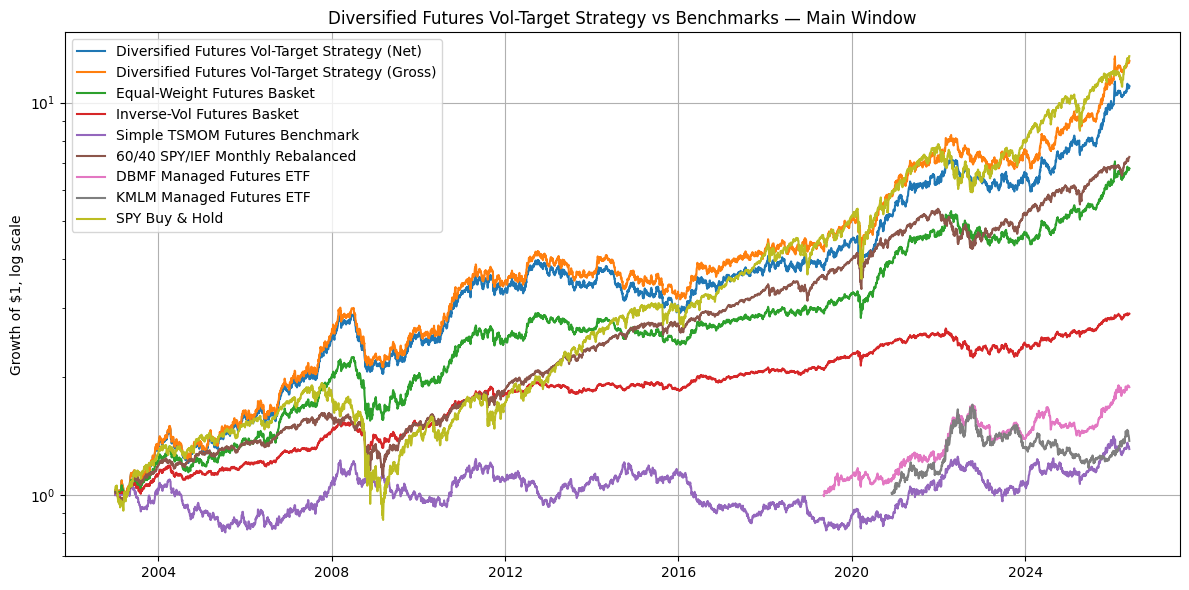

Saved: outputs/equity_curve_recent_window.png


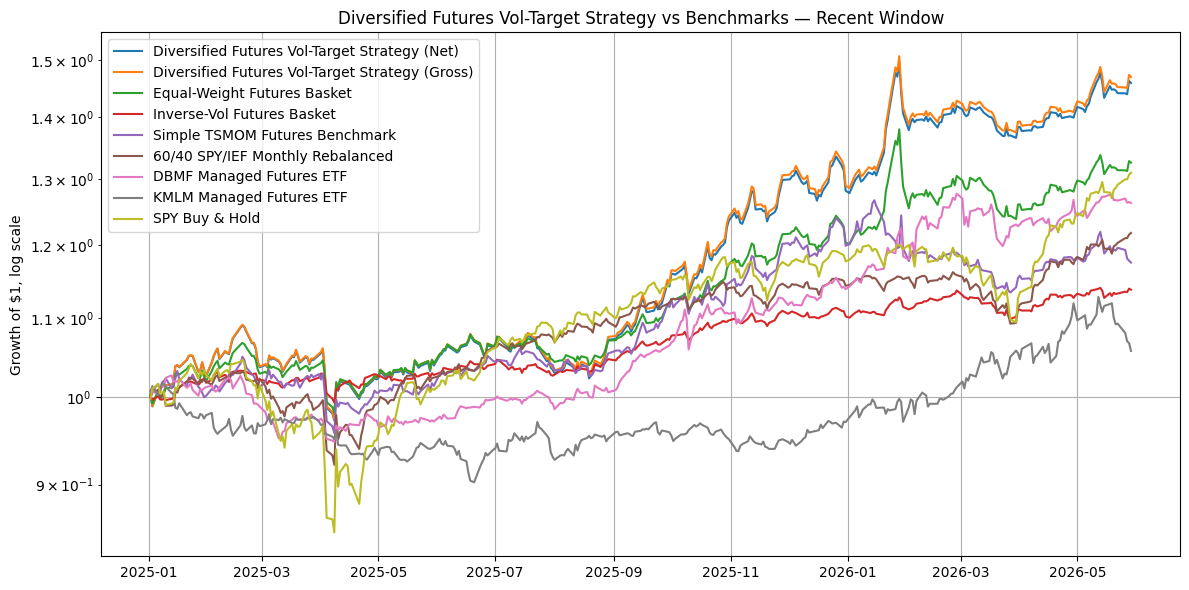

Saved: outputs/drawdown_main_window.png


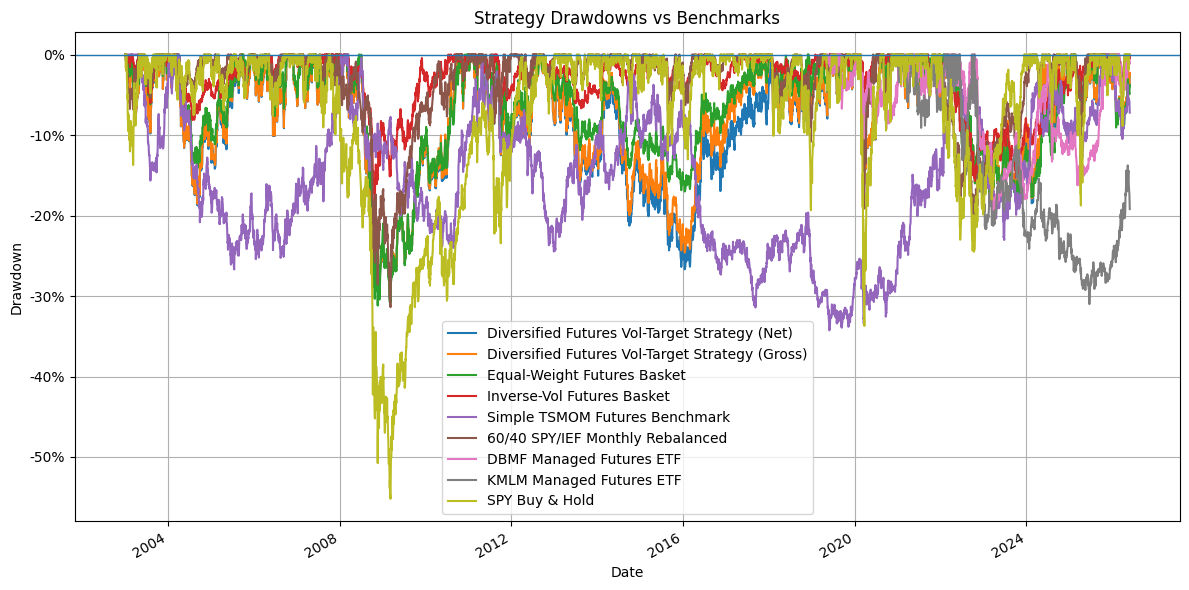

Saved: outputs/rolling_volatility_main_window.png


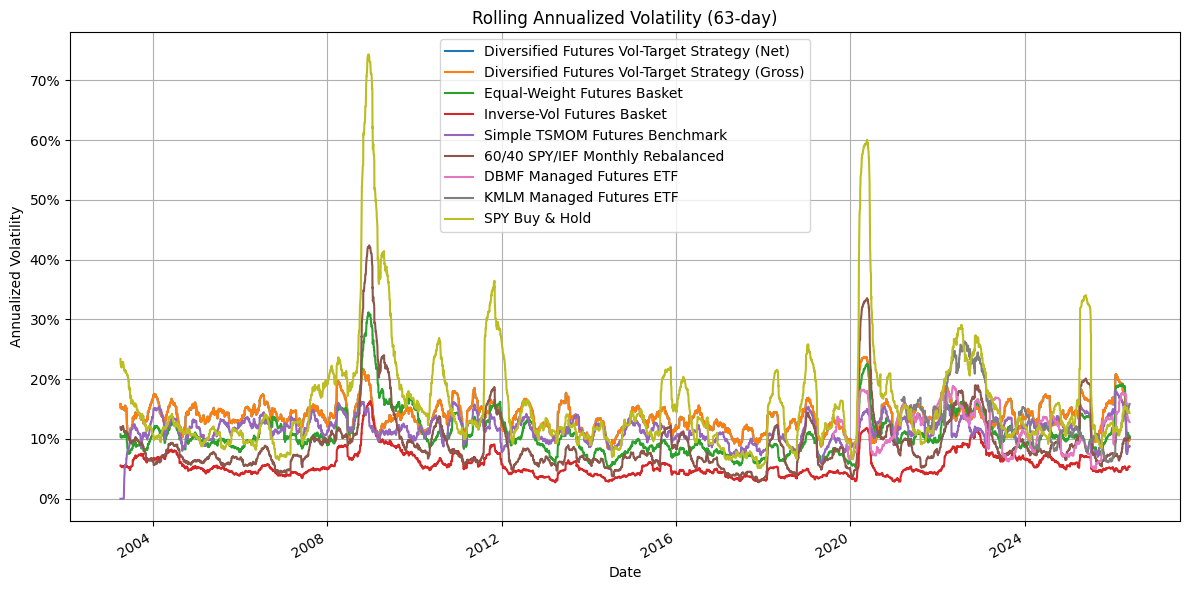

Saved: outputs/rolling_sharpe_main_window.png


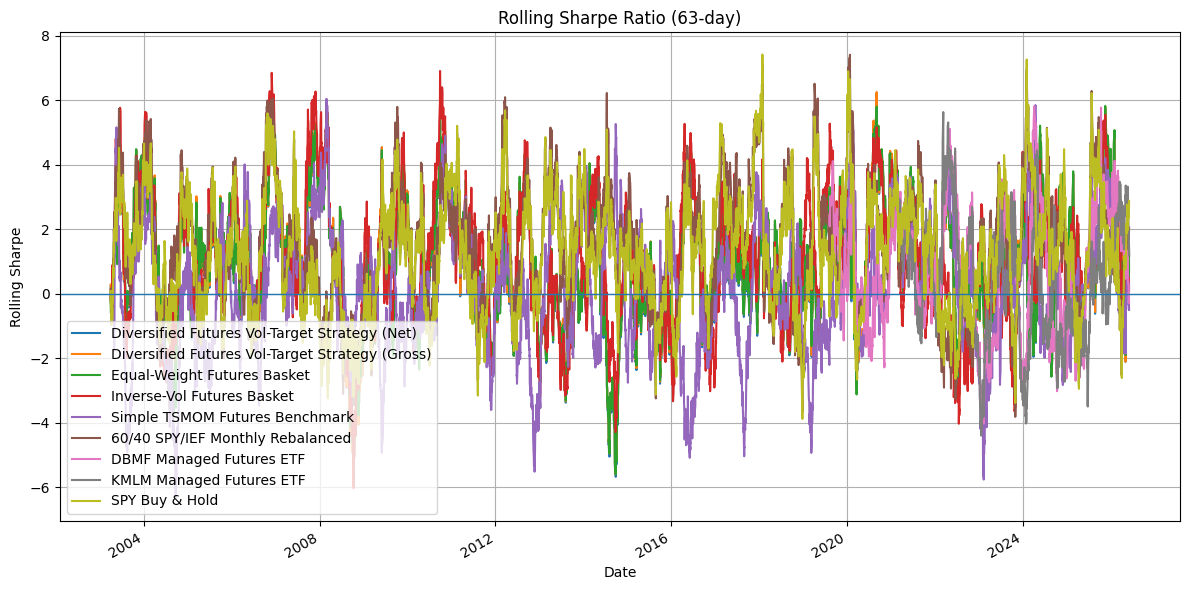

Saved: outputs/underwater_plot_main_window.png


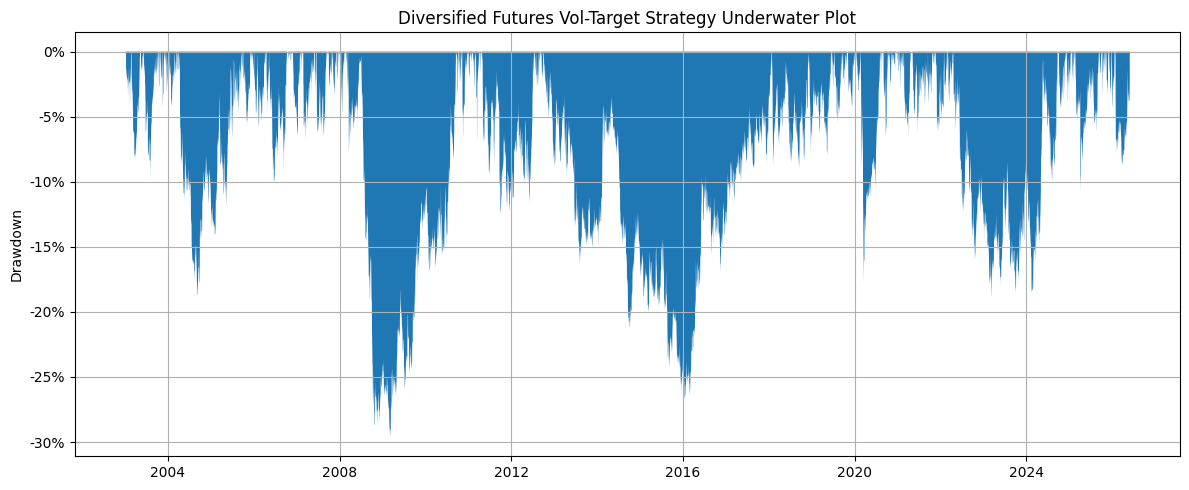

Saved: outputs/monthly_returns_main_window.png


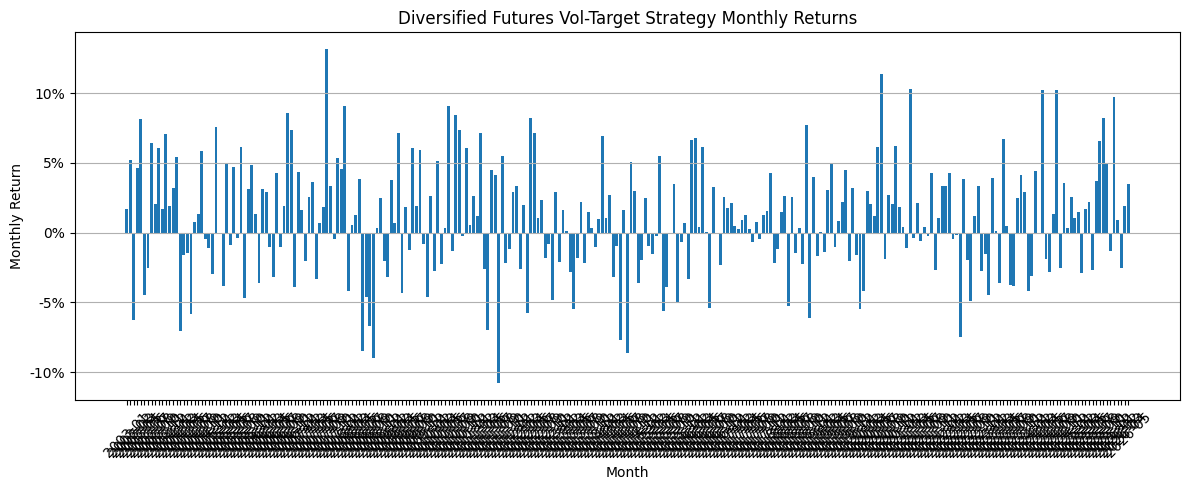

Saved: outputs/effective_exposure_main_window.png


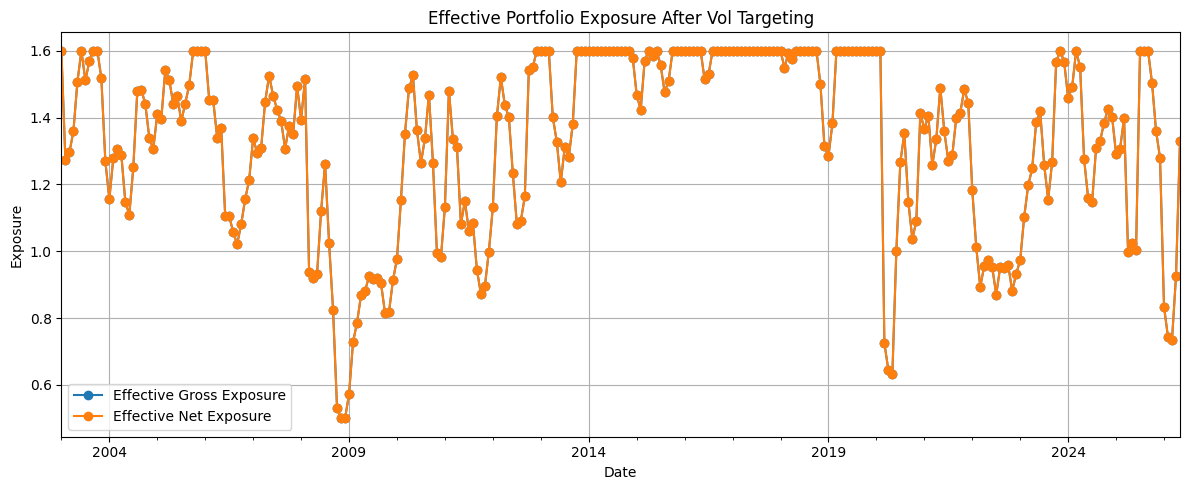

Saved: outputs/effective_asset_weights_main_window.png


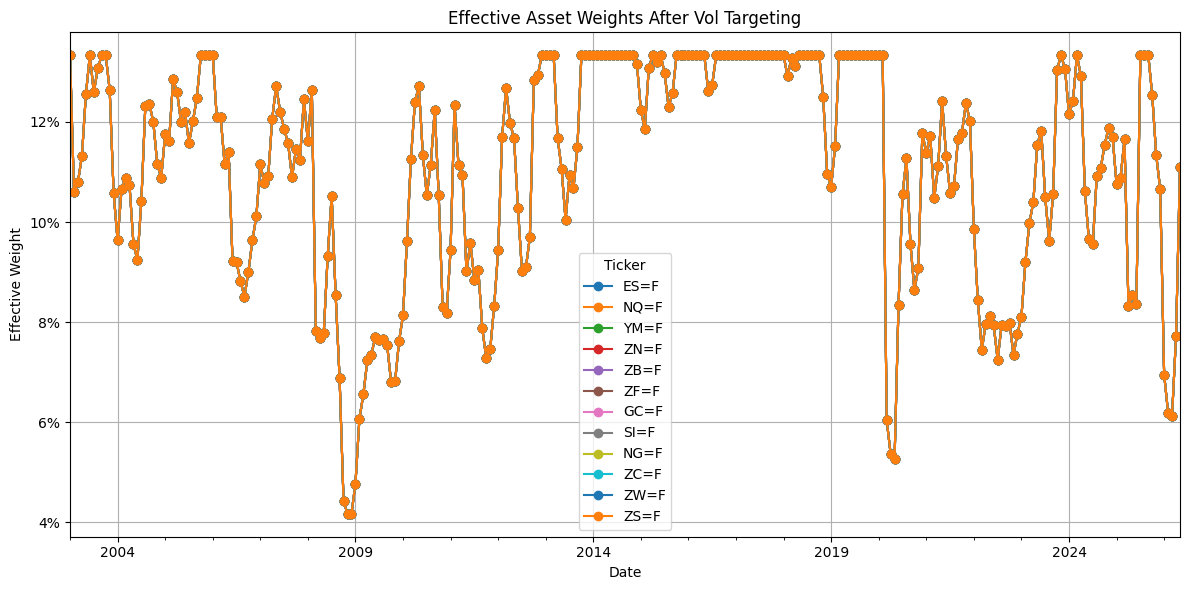

Saved: outputs/asset_class_exposure_main_window.png


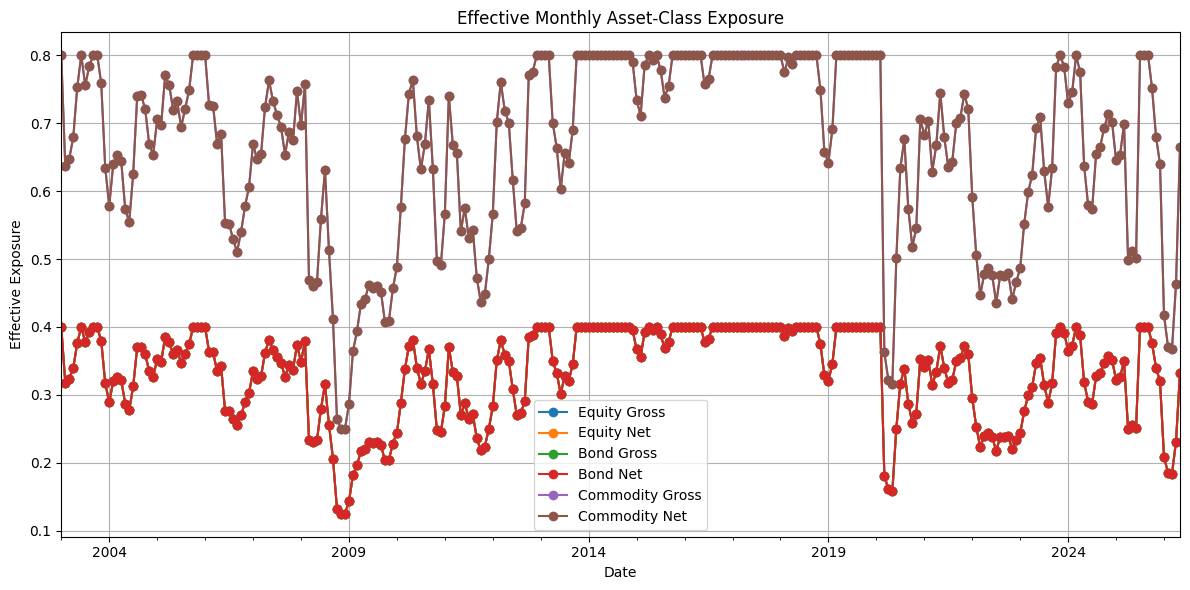

Latest 12 monthly asset-class exposure observations:


,Equity Gross,Equity Net,Bond Gross,Bond Net,Commodity Gross,Commodity Net
Date,,,,,,
2025-06-30,0.251006,0.251006,0.251006,0.251006,0.502013,0.502013
2025-07-31,0.400000,0.400000,0.400000,0.400000,0.800000,0.800000
2025-08-31,0.400000,0.400000,0.400000,0.400000,0.800000,0.800000
2025-09-30,0.400000,0.400000,0.400000,0.400000,0.800000,0.800000
2025-10-31,0.375913,0.375913,0.375913,0.375913,0.751826,0.751826
2025-11-30,0.340143,0.340143,0.340143,0.340143,0.680287,0.680287
2025-12-31,0.319882,0.319882,0.319882,0.319882,0.639764,0.639764
2026-01-31,0.208530,0.208530,0.208530,0.208530,0.417060,0.417060
2026-02-28,0.185582,0.185582,0.185582,0.185582,0.371164,0.371164


Saved: outputs/rolling_beta_spy_main_window.png


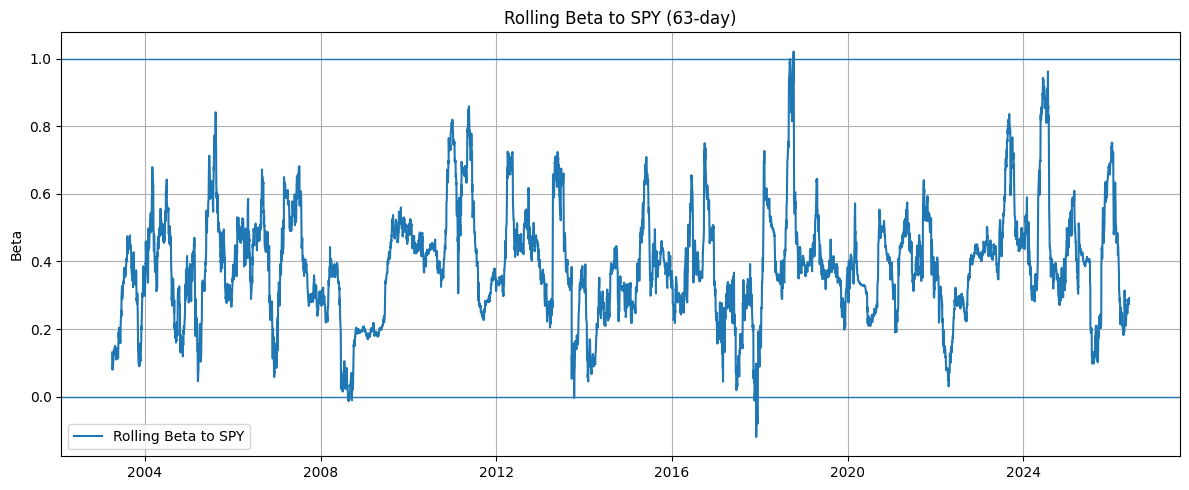

Saved: outputs/rolling_var_breach_diagnostic_main_window.png


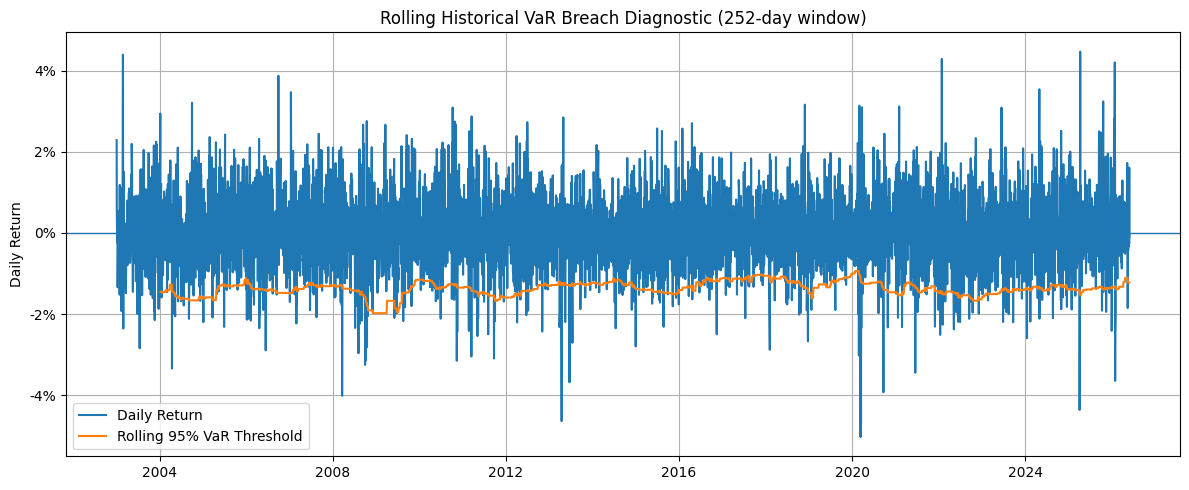

In [ ]:
# =============================================================================
# 8. Diagnostic plots
# =============================================================================

plot_equity_curve(
    comparison,
    title="Diversified Futures Vol-Target Strategy vs Benchmarks — Main Window",
    filename="equity_curve_main_window.png",
)

plot_equity_curve(
    comparison_recent,
    title="Diversified Futures Vol-Target Strategy vs Benchmarks — Recent Window",
    filename="equity_curve_recent_window.png",
)

plot_drawdown_curve(
    comparison,
    filename="drawdown_main_window.png",
)

plot_rolling_volatility(
    comparison,
    window=63,
    filename="rolling_volatility_main_window.png",
)

plot_rolling_sharpe(
    comparison,
    window=63,
    filename="rolling_sharpe_main_window.png",
)

plot_strategy_underwater(
    strategy_returns_net,
    filename="underwater_plot_main_window.png",
)

plot_monthly_returns(
    strategy_returns_net,
    filename="monthly_returns_main_window.png",
)

plot_effective_exposure(
    strategy_daily_weights.loc[pd.Timestamp(evaluation_start):],
    strategy_leverage.loc[pd.Timestamp(evaluation_start):],
    freq="ME",
    filename="effective_exposure_main_window.png",
)

plot_effective_asset_weights(
    strategy_daily_weights.loc[pd.Timestamp(evaluation_start):],
    strategy_leverage.loc[pd.Timestamp(evaluation_start):],
    min_abs_weight=0.01,
    freq="ME",
    filename="effective_asset_weights_main_window.png",
)

asset_class_exposure = plot_asset_class_exposure(
    strategy_daily_weights.loc[pd.Timestamp(evaluation_start):],
    strategy_leverage.loc[pd.Timestamp(evaluation_start):],
    freq="ME",
    filename="asset_class_exposure_main_window.png",
)

print("Latest 12 monthly asset-class exposure observations:")
display(asset_class_exposure.tail(12))

plot_rolling_beta_to_spy(
    strategy_returns_net,
    spy_returns_clean,
    window=63,
    filename="rolling_beta_spy_main_window.png",
)

plot_rolling_var(
    strategy_returns_net,
    window=252,
    confidence=0.95,
    filename="rolling_var_breach_diagnostic_main_window.png",
)

In [ ]:
# =============================================================================
# 9. Stress-window tests
# =============================================================================

stress_windows = {
    "Global Financial Crisis": ("2008-01-01", "2009-03-31"),
    "Eurozone / Risk-Off": ("2011-07-01", "2011-12-31"),
    "Oil Crash / Dollar Shock": ("2014-07-01", "2016-02-29"),
    "Volmageddon / Q4 2018": ("2018-02-01", "2018-12-31"),
    "COVID Crash": ("2020-02-01", "2020-04-30"),
    "2022 Inflation / Rates Shock": ("2022-01-01", "2022-12-31"),
    "2025 Recent Window": ("2025-01-01", "2026-05-29"),
}

def stress_test_table(
    comparison: pd.DataFrame,
    windows: dict,
    risk_free_daily: Optional[pd.Series] = None,
    spy_returns: Optional[pd.Series] = None,
) -> pd.DataFrame:
    """
    Calculate performance statistics over named stress windows.

    Adds actual available start/end dates to avoid overstating coverage.
    Skips windows with insufficient available data.
    """
    rows = []

    for window_name, (start, finish) in windows.items():
        requested_start = pd.Timestamp(start)
        requested_finish = pd.Timestamp(finish)

        window_data = comparison.loc[requested_start:requested_finish]

        if len(window_data) < 21:
            rows.append({
                "Window": window_name,
                "Series": "Insufficient data",
                "Requested Start": requested_start,
                "Requested End": requested_finish,
                "Available Start": pd.NaT,
                "Available End": pd.NaT,
                "Observations": len(window_data),
                "Annual Return": np.nan,
                "Annual Volatility": np.nan,
                "Sharpe": np.nan,
                "Max Drawdown": np.nan,
                "Calmar": np.nan,
                "Win Rate": np.nan,
                "Total Return": np.nan,
            })
            continue

        for col in window_data.columns:
            stats_row = performance_stats(
                window_data[col],
                risk_free_daily=risk_free_daily,
                spy_returns=spy_returns,
            )

            rows.append({
                "Window": window_name,
                "Series": col,
                "Requested Start": requested_start,
                "Requested End": requested_finish,
                "Available Start": window_data.index.min(),
                "Available End": window_data.index.max(),
                "Observations": len(window_data),
                "Annual Return": stats_row["Annual Return"],
                "Annual Volatility": stats_row["Annual Volatility"],
                "Sharpe": stats_row["Sharpe"],
                "Max Drawdown": stats_row["Max Drawdown"],
                "Calmar": stats_row["Calmar"],
                "Win Rate": stats_row["Win Rate"],
                "Total Return": stats_row["Total Return"],
            })

    out = pd.DataFrame(rows)

    ordered_cols = [
        "Window",
        "Series",
        "Requested Start",
        "Requested End",
        "Available Start",
        "Available End",
        "Observations",
        "Annual Return",
        "Annual Volatility",
        "Sharpe",
        "Max Drawdown",
        "Calmar",
        "Win Rate",
        "Total Return",
    ]

    return out[ordered_cols]



stress_results = stress_test_table(
    comparison_full,
    stress_windows,
    risk_free_daily=risk_free_daily,
    spy_returns=spy_returns_clean,
)

print("Stress-window performance:")
display(format_stats(stress_results.set_index(["Window", "Series"])))

Stress-window performance:


Requested Start  \
Window                  Series                                                            
Global Financial Crisis Diversified Futures Vol-Target Strategy (Net)        2008-01-01   
                        Diversified Futures Vol-Target Strategy (Gross)      2008-01-01   
                        Equal-Weight Futures Basket                          2008-01-01   
                        Inverse-Vol Futures Basket                           2008-01-01   
                        Simple TSMOM Futures Benchmark                       2008-01-01   
...                                                                                 ...   
2025 Recent Window      Simple TSMOM Futures Benchmark                       2025-01-01   
                        60/40 SPY/IEF Monthly Rebalanced                     2025-01-01   
                        DBMF Managed Futures ETF                             2025-01-01   
                        KMLM Managed Futures ETF                             2025-01-01   
                        SPY Buy & Hold                                       2025-01-01   

                                                                        Requested End  \
Window                  Series                                                          
Global Financial Crisis Diversified Futures Vol-Target Strategy (Net)      2009-03-31   
                        Diversified Futures Vol-Target Strategy (Gross)    2009-03-31   
                        Equal-Weight Futures Basket                        2009-03-31   
                        Inverse-Vol Futures Basket                         2009-03-31   
                        Simple TSMOM Futures Benchmark                     2009-03-31   
...                                                                               ...   
2025 Recent Window      Simple TSMOM Futures Benchmark                     2026-05-29   
                        60/40 SPY/IEF Monthly Rebalanced                   2026-05-29   
                        DBMF Managed Futures ETF                           2026-05-29   
                        KMLM Managed Futures ETF                           2026-05-29   
                        SPY Buy & Hold                                     2026-05-29   

                                                                        Available Start  \
Window                  Series                                                            
Global Financial Crisis Diversified Futures Vol-Target Strategy (Net)        2008-01-02   
                        Diversified Futures Vol-Target Strategy (Gross)      2008-01-02   
                        Equal-Weight Futures Basket                          2008-01-02   
                        Inverse-Vol Futures Basket                           2008-01-02   
                        Simple TSMOM Futures Benchmark                       2008-01-02   
...                                                                                 ...   
2025 Recent Window      Simple TSMOM Futures Benchmark                       2025-01-02   
                        60/40 SPY/IEF Monthly Rebalanced                     2025-01-02   
                        DBMF Managed Futures ETF                             2025-01-02   
                        KMLM Managed Futures ETF                             2025-01-02   
                        SPY Buy & Hold                                       2025-01-02   

                                                                        Available End  \
Window                  Series                                                          
Global Financial Crisis Diversified Futures Vol-Target Strategy (Net)      2009-03-31   
                        Diversified Futures Vol-Target Strategy (Gross)    2009-03-31   
                        Equal-Weight Futures Basket                        2009-03-31   
                        Inverse-Vol Futures Basket                         2009-03-31   
            

In [ ]:
stress_summary = stress_results[
    stress_results["Series"] == "Diversified Futures Vol-Target Strategy (Net)"
].copy()

display(format_stats(stress_summary.set_index("Window")))

,Series,Requested Start,Requested End,Available Start,Available End,Observations,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Calmar,Win Rate,Total Return
Window,,,,,,,,,,,,,
Global Financial Crisis,Diversified Futures Vol-Target Strategy (Net),2008-01-01,2009-03-31,2008-01-02,2009-03-31,307,-11.16%,16.32%,-0.71,-29.61%,-0.38,50.49%,-13.43%
Eurozone / Risk-Off,Diversified Futures Vol-Target Strategy (Net),2011-07-01,2011-12-31,2011-07-01,2011-12-30,127,-2.12%,14.39%,-0.08,-11.22%,-0.19,53.54%,-1.08%
Oil Crash / Dollar Shock,Diversified Futures Vol-Target Strategy (Net),2014-07-01,2016-02-29,2014-07-01,2016-02-29,419,-12.82%,13.24%,-0.97,-20.79%,-0.62,47.97%,-20.40%
Volmageddon / Q4 2018,Diversified Futures Vol-Target Strategy (Net),2018-02-01,2018-12-31,2018-02-01,2018-12-31,228,-4.90%,13.78%,-0.44,-8.34%,-0.59,50.00%,-4.45%
COVID Crash,Diversified Futures Vol-Target Strategy (Net),2020-02-01,2020-04-30,2020-02-03,2020-04-30,62,-24.60%,23.81%,-1.09,-17.82%,-1.38,53.23%,-6.71%
2022 Inflation / Rates Shock,Diversified Futures Vol-Target Strategy (Net),2022-01-01,2022-12-31,2022-01-03,2022-12-30,251,0.95%,15.13%,0.01,-15.95%,0.06,51.39%,0.95%
2025 Recent Window,Diversified Futures Vol-Target Strategy (Net),2025-01-01,2026-05-29,2025-01-02,2026-05-29,353,30.94%,14.95%,1.62,-10.80%,2.87,55.24%,45.87%


In [ ]:
# =============================================================================
# 10. Sensitivity checks
# =============================================================================

def run_sensitivity_grid(
    prices: pd.DataFrame,
    spy: pd.Series,
    spy_returns_clean: pd.Series,
    risk_free_daily: pd.Series,
    target_vol_values: list,
    max_leverage_values: list,
    normal_gross_cap_values: list,
    evaluation_start: str,
    transaction_cost_bps: float = 2.0,
) -> pd.DataFrame:
    """
    Run a compact parameter sensitivity grid.

    The purpose is not to overfit parameters, but to show that the strategy is
    not dependent on one fragile setting.
    """
    rows = []

    equal_weight_futures_returns = run_equal_weight_monthly_benchmark(
        prices=prices,
        rebalance_rule=rebalance_rule,
    )

    for tv in target_vol_values:
        for ml in max_leverage_values:
            for gc in normal_gross_cap_values:
                test_results = run_diversified_futures_strategy(
                    prices=prices,
                    spy=spy,
                    target_vol=tv,
                    max_leverage=ml,
                    min_leverage=min_leverage,
                    normal_gross_cap=gc,
                    warning_gross_cap=warning_gross_cap,
                    crisis_gross_cap=crisis_gross_cap,
                    warning_spy_trend_threshold=warning_spy_trend_threshold,
                    crisis_spy_trend_threshold=crisis_spy_trend_threshold,
                    equity_crisis_multiplier=equity_crisis_multiplier,
                    bond_hedge_weight=bond_hedge_weight,
                    transaction_cost_bps=transaction_cost_bps,
                    transaction_cost_bps_by_ticker=transaction_cost_bps_by_ticker,
                    rebalance_rule=rebalance_rule,
                    vol_lookback=vol_lookback,
                    trend_filter_enabled=trend_filter_enabled,
                    trend_lookback=trend_lookback,
                    trend_filter_mode=trend_filter_mode,
                    drawdown_derisking_enabled=drawdown_derisking_enabled,
                    drawdown_warning_threshold=drawdown_warning_threshold,
                    drawdown_crisis_threshold=drawdown_crisis_threshold,
                    drawdown_warning_multiplier=drawdown_warning_multiplier,
                    drawdown_crisis_multiplier=drawdown_crisis_multiplier,
                )

                test_returns = test_results["strategy_returns_net"]

                test_comparison = pd.concat(
                    {
                        "Strategy": test_returns,
                        "Equal-Weight Futures Basket": equal_weight_futures_returns,
                        "SPY Buy & Hold": spy_returns_clean,
                    },
                    axis=1,
                ).dropna()

                test_comparison = test_comparison.loc[pd.Timestamp(evaluation_start):]

                if test_comparison.empty:
                    continue

                s = performance_stats(
                    test_comparison["Strategy"],
                    risk_free_daily=risk_free_daily,
                    spy_returns=spy_returns_clean,
                )

                rs = risk_stats(test_comparison["Strategy"])

                rows.append({
                    "Target Vol": tv,
                    "Max Leverage": ml,
                    "Normal Gross Cap": gc,
                    "Annual Return": s["Annual Return"],
                    "Annual Volatility": s["Annual Volatility"],
                    "Sharpe": s["Sharpe"],
                    "Max Drawdown": s["Max Drawdown"],
                    "Calmar": s["Calmar"],
                    "Win Rate": s["Win Rate"],
                    "Daily VaR 95": rs["Daily VaR 95"],
                    "Daily Expected Shortfall 95": rs["Daily Expected Shortfall 95"],
                    "Tail Ratio": rs["Tail Ratio"],
                    "Total Return": s["Total Return"],
                })

    sensitivity = pd.DataFrame(rows)

    if sensitivity.empty:
        return sensitivity

    sensitivity = sensitivity.sort_values(
        by=["Sharpe", "Calmar", "Total Return"],
        ascending=False,
    )

    return sensitivity


sensitivity_results = run_sensitivity_grid(
    prices=prices,
    spy=spy,
    spy_returns_clean=spy_returns_clean,
    risk_free_daily=risk_free_daily,
    target_vol_values=[0.12, 0.14, 0.16],
    max_leverage_values=[1.20, 1.35, 1.50],
    normal_gross_cap_values=[1.20, 1.30, 1.40],
    evaluation_start=evaluation_start,
    transaction_cost_bps=transaction_cost_bps,
)

print("Parameter sensitivity results:")
display(
    format_stats(
        sensitivity_results.set_index(
            ["Target Vol", "Max Leverage", "Normal Gross Cap"]
        )
    )
)

print("Top 10 sensitivity configurations:")
display(
    format_stats(
        sensitivity_results
        .head(10)
        .set_index(["Target Vol", "Max Leverage", "Normal Gross Cap"])
    )
)

print(
    "Note: repeated sensitivity results can occur when leverage or gross-exposure "
    "constraints are not binding, or when another cap dominates the tested parameter."
)



Parameter sensitivity results:


Annual Return Annual Volatility  \
Target Vol Max Leverage Normal Gross Cap                                   
0.14       1.50         1.4                     11.06%            13.33%   
           1.35         1.4                     10.87%            13.09%   
0.16       1.50         1.4                     11.48%            14.12%   
0.14       1.35         1.3                     10.58%            12.82%   
           1.50         1.3                     10.58%            12.82%   
0.16       1.35         1.4                     11.17%            13.79%   
0.12       1.35         1.3                      9.81%            11.80%   
           1.50         1.3                      9.81%            11.80%   
0.16       1.35         1.3                     10.85%            13.45%   
           1.50         1.3                     10.85%            13.45%   
0.12       1.35         1.4                      9.87%            11.94%   
           1.50         1.4                      9.94%            12.05%   
           1.20         1.2                      9.54%            11.44%   
                        1.3                      9.54%            11.44%   
                        1.4                      9.54%            11.44%   
           1.35         1.2                      9.54%            11.44%   
           1.50         1.2                      9.54%            11.44%   
0.14       1.20         1.2                      9.95%            12.20%   
                        1.3                      9.95%            12.20%   
                        1.4                      9.95%            12.20%   
           1.35         1.2                      9.95%            12.20%   
           1.50         1.2                      9.95%            12.20%   
0.16       1.20         1.2                     10.13%            12.69%   
                        1.3                     10.13%            12.69%   
                        1.4                     10.13%            12.69%   
           1.35         1.2                     10.13%            12.69%   
           1.50         1.2                     10.13%            12.69%   

                                         Sharpe Max Drawdown Calmar Win Rate  \
Target Vol Max Leverage Normal Gross Cap                                       
0.14       1.50         1.4                0.73      -29.57%   0.37   53.00%   
           1.35         1.4                0.73      -29.57%   0.37   53.00%   
0.16       1.50         1.4                0.72      -32.95%   0.35   53.01%   
0.14       1.35         1.3                0.72      -29.57%   0.36   53.00%   
           1.50         1.3                0.72      -29.57%   0.36   53.00%   
0.16       1.35         1.4                0.72      -32.49%   0.34   53.01%   
0.12       1.35         1.3                0.71      -25.70%   0.38   53.00%   
           1.50         1.3                0.71      -25.70%   0.38   53.00%   
0.16       1.35         1.3                0.71      -32.12%   0.34   53.01%   
           1.50         1.3                0.71      -32.12%   0.34   53.01%   
0.12       1.35         1.4                0.71      -25.70%   0.38   53.00%   
           1.50         1.4                0.71      -25.70%   0.39   53.00%   
           1.20         1.2                0.71      -25.70%   0.37   53.00%   
                        1.3                0.71      -25.70%   0.37   53.00%   
                        1.4                0.71      -25.70%   0.37   53.00%   
           1.35         1.2                0.71      -25.70%   0.37   53.00%   
           1.50         1.2                0.71      -25.70%   0.37   53.00%   
0.14       1.20         1.2                0.70      -28.96%   0.34   53.01%   
                        1.3                0.70      -28.96%   0.34   53.01%   
                        1.4                0.70      -28.96%   0.34   53.01%   
           1.35         1.2                0.70      -28.96%   0.34   53.01%

Top 10 sensitivity configurations:


Annual Return Annual Volatility  \
Target Vol Max Leverage Normal Gross Cap                                   
0.14       1.50         1.4                     11.06%            13.33%   
           1.35         1.4                     10.87%            13.09%   
0.16       1.50         1.4                     11.48%            14.12%   
0.14       1.35         1.3                     10.58%            12.82%   
           1.50         1.3                     10.58%            12.82%   
0.16       1.35         1.4                     11.17%            13.79%   
0.12       1.35         1.3                      9.81%            11.80%   
           1.50         1.3                      9.81%            11.80%   
0.16       1.35         1.3                     10.85%            13.45%   
           1.50         1.3                     10.85%            13.45%   

                                         Sharpe Max Drawdown Calmar Win Rate  \
Target Vol Max Leverage Normal Gross Cap                                       
0.14       1.50         1.4                0.73      -29.57%   0.37   53.00%   
           1.35         1.4                0.73      -29.57%   0.37   53.00%   
0.16       1.50         1.4                0.72      -32.95%   0.35   53.01%   
0.14       1.35         1.3                0.72      -29.57%   0.36   53.00%   
           1.50         1.3                0.72      -29.57%   0.36   53.00%   
0.16       1.35         1.4                0.72      -32.49%   0.34   53.01%   
0.12       1.35         1.3                0.71      -25.70%   0.38   53.00%   
           1.50         1.3                0.71      -25.70%   0.38   53.00%   
0.16       1.35         1.3                0.71      -32.12%   0.34   53.01%   
           1.50         1.3                0.71      -32.12%   0.34   53.01%   

                                         Daily VaR 95  \
Target Vol Max Leverage Normal Gross Cap                
0.14       1.50         1.4                     1.31%   
           1.35         1.4                     1.28%   
0.16       1.50         1.4                     1.36%   
0.14       1.35         1.3                     1.25%   
           1.50         1.3                     1.25%   
0.16       1.35         1.4                     1.33%   
0.12       1.35         1.3                     1.16%   
           1.50         1.3                     1.16%   
0.16       1.35         1.3                     1.29%   
           1.50         1.3                     1.29%   

                                         Daily Expected Shortfall 95  \
Target Vol Max Leverage Normal Gross Cap                               
0.14       1.50         1.4                                    1.82%   
           1.35         1.4                                    1.79%   
0.16       1.50         1.4                                    1.95%   
0.14       1.35         1.3                                    1.76%   
           1.50         1.3                                    1.76%   
0.16       1.35         1.4                                    1.90%   
0.12       1.35         1.3                                    1.61%   
           1.50         1.3                                    1.61%   
0.16       1.35         1.3                                    1.86%   
           1.50         1.3                                    1.86%   

                                         Tail Ratio Total Return  
Target Vol Max Leverage Normal Gross Cap                          
0.14       1.50         1.4                    1.08     1045.73%  
           1.35         1.4                    1.09     1000.83%  
0.16       1.50         1.4                    1.09     1149.38%  
0.14       1.35         1.3                    1.09      936.25%  
           1.50         1.3                    1.09      936.25%  
0.16       1.35         1.4                    1.10     1072.14%  
0.12       1.35         1.3                    1.08      779.45%  
           1.5

Note: repeated sensitivity results can occur when leverage or gross-exposure constraints are not binding, or when another cap dominates the tested parameter.


In [ ]:
# =============================================================================
# 10B. Transaction cost sensitivity
# =============================================================================

def scale_transaction_costs(
    base_cost_dict: dict,
    multiplier: float,
) -> dict:
    """
    Scale ticker-level transaction-cost assumptions by a multiplier.
    """
    return {
        ticker: cost_bps * multiplier
        for ticker, cost_bps in base_cost_dict.items()
    }


def run_transaction_cost_sensitivity(
    prices: pd.DataFrame,
    spy: pd.Series,
    spy_returns_clean: pd.Series,
    risk_free_daily: pd.Series,
    cost_multipliers: list,
    evaluation_start: str,
) -> pd.DataFrame:
    """
    Test whether the strategy survives higher or lower transaction-cost assumptions.
    """
    rows = []

    for multiplier in cost_multipliers:
        scaled_costs = scale_transaction_costs(
            transaction_cost_bps_by_ticker,
            multiplier,
        )

        test_results = run_diversified_futures_strategy(
            prices=prices,
            spy=spy,
            target_vol=target_vol,
            max_leverage=max_leverage,
            min_leverage=min_leverage,
            normal_gross_cap=normal_gross_cap,
            warning_gross_cap=warning_gross_cap,
            crisis_gross_cap=crisis_gross_cap,
            warning_spy_trend_threshold=warning_spy_trend_threshold,
            crisis_spy_trend_threshold=crisis_spy_trend_threshold,
            equity_crisis_multiplier=equity_crisis_multiplier,
            bond_hedge_weight=bond_hedge_weight,
            transaction_cost_bps=transaction_cost_bps * multiplier,
            transaction_cost_bps_by_ticker=scaled_costs,
            margin_financing_spread=margin_financing_spread,
            rebalance_rule=rebalance_rule,
            vol_lookback=vol_lookback,
            trend_filter_enabled=trend_filter_enabled,
            trend_lookback=trend_lookback,
            trend_filter_mode=trend_filter_mode,
            trend_filter_asset_classes=trend_filter_asset_classes,
            drawdown_derisking_enabled=drawdown_derisking_enabled,
            drawdown_warning_threshold=drawdown_warning_threshold,
            drawdown_crisis_threshold=drawdown_crisis_threshold,
            drawdown_warning_multiplier=drawdown_warning_multiplier,
            drawdown_crisis_multiplier=drawdown_crisis_multiplier,
        )

        test_returns = test_results["strategy_returns_net"]

        test_comparison = pd.concat(
            {
                "Strategy": test_returns,
                "SPY Buy & Hold": spy_returns_clean,
            },
            axis=1,
        ).dropna()

        test_comparison = test_comparison.loc[pd.Timestamp(evaluation_start):]

        if test_comparison.empty:
            continue

        s = performance_stats(
            test_comparison["Strategy"],
            risk_free_daily=risk_free_daily,
            spy_returns=spy_returns_clean,
        )

        rs = risk_stats(test_comparison["Strategy"])

        total_cost_drag = (
            test_results["transaction_costs"]
            .reindex(test_comparison.index)
            .fillna(0.0)
            .sum()
        )

        annualized_cost_drag = (
            test_results["transaction_costs"]
            .reindex(test_comparison.index)
            .fillna(0.0)
            .mean()
            * 252.0
        )

        monthly_turnover_test = (
            test_results["turnover"]
            .reindex(test_comparison.index)
            .fillna(0.0)
            .resample("ME")
            .sum()
        )

        rows.append({
            "Cost Multiplier": multiplier,
            "Average Cost Bps": pd.Series(scaled_costs).mean(),
            "Annual Return": s["Annual Return"],
            "Annual Volatility": s["Annual Volatility"],
            "Sharpe": s["Sharpe"],
            "Max Drawdown": s["Max Drawdown"],
            "Calmar": s["Calmar"],
            "Daily Expected Shortfall 95": rs["Daily Expected Shortfall 95"],
            "Total Return": s["Total Return"],
            "Total Cost Drag": total_cost_drag,
            "Annualized Cost Drag": annualized_cost_drag,
            "Annualized Turnover": monthly_turnover_test.mean() * 12.0,
            "Cost Drag / Annual Return": (
                annualized_cost_drag / s["Annual Return"]
                if pd.notna(s["Annual Return"]) and abs(s["Annual Return"]) > 1e-12
                else np.nan
                ),
        })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    return out.sort_values("Cost Multiplier")


cost_sensitivity_results = run_transaction_cost_sensitivity(
    prices=prices,
    spy=spy,
    spy_returns_clean=spy_returns_clean,
    risk_free_daily=risk_free_daily,
    cost_multipliers=[0.5, 1.0, 2.0, 3.0, 5.0, 10.0],
    evaluation_start=evaluation_start,
)

print("Transaction cost sensitivity:")
display(format_stats(cost_sensitivity_results.set_index("Cost Multiplier")))

Transaction cost sensitivity:


,Average Cost Bps,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Calmar,Daily Expected Shortfall 95,Total Return,Total Cost Drag,Annualized Cost Drag,Annualized Turnover,Cost Drag / Annual Return
Cost Multiplier,,,,,,,,,,,,
0.5,2.092308,10.93%,13.96%,0.69,-29.57%,0.37,1.90%,1015.42%,0.011459,0.000493,2.531222,0.004509
1.0,4.184615,10.88%,13.96%,0.69,-29.61%,0.37,1.90%,1002.71%,0.022919,0.000986,2.531222,0.009064
2.0,8.369231,10.77%,13.96%,0.68,-29.69%,0.36,1.91%,977.72%,0.045838,0.001972,2.531222,0.018311
3.0,12.553846,10.66%,13.97%,0.68,-29.76%,0.36,1.91%,953.30%,0.068756,0.002958,2.531222,0.027748
5.0,20.923077,10.44%,13.97%,0.66,-29.91%,0.35,1.91%,906.10%,0.114594,0.004930,2.531222,0.047212
10.0,41.846154,9.90%,13.97%,0.63,-30.29%,0.33,1.92%,797.14%,0.229188,0.009861,2.531222,0.099606
